### Exploratory Data Analysis(EDA)

### Solar Power Plant Dataset Overview

This dataset has been collected from **two solar power plants in India** over a period of **34 days**. It contains:

- **Two pairs of files**:
  - Each pair includes:
    - A **power generation** dataset
    - A **sensor readings** dataset

###  Data Structure

- **Power Generation Data**:
  - Collected at the **inverter level**
  - Each inverter is connected to **multiple lines of solar panels**

- **Sensor Data**:
  - Collected at the **plant level**
  - Single array of **optimally placed sensors** (e.g., irradiance, temperature, etc.)


In [91]:
# import packages

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.ensemble import StackingRegressor, VotingRegressor, RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV
from sklearn.datasets import make_regression
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
import pickle
from scipy.stats import shapiro
# from google.colab import drive
from scipy.stats import probplot, shapiro, f_oneway, pearsonr

In [92]:
# drive.mount('/content/drive')

filepath1 = 'dataset\Plant_1_Generation_Data.csv'
filepath2 = 'dataset\Plant_1_Weather_Sensor_Data.csv'

In [93]:
#load dataset

df_plant_1_gen = pd.read_csv(filepath1)
df_plant_1_weather = pd.read_csv(filepath2)
# df_plant_2_gen = pd.read_csv('dataset/Plant_2_Generation_Data.csv')
# df_plant_2_weather = pd.read_csv('dataset/Plant_1_Weather_Sensor_Data.csv')

#### Data Inspection

In [94]:
data_list = [df_plant_1_gen]

In [95]:
for i in data_list:
    print('***************************************\n')
    print(f'This dataset has {i.shape[0]} rows and {i.shape[1]} columns.')
    print('---------------------------------------\n')
    print(i.head(5))
    print('---------------------------------------\n')
    print(i.info())
    print("No column contains Null values.")
    print('---------------------------------------\n')
    print(i.describe())
    print("PLANT_ID has no duplicated and is the primary key.\n\n")
    print('---------------------------------------\n')
    print(f'Number of unique values in SOURCE_KEY column: {i["SOURCE_KEY"].nunique()}')



***************************************

This dataset has 68778 rows and 7 columns.
---------------------------------------

          DATE_TIME  PLANT_ID       SOURCE_KEY  DC_POWER  AC_POWER  \
0  15-05-2020 00:00   4135001  1BY6WEcLGh8j5v7       0.0       0.0   
1  15-05-2020 00:00   4135001  1IF53ai7Xc0U56Y       0.0       0.0   
2  15-05-2020 00:00   4135001  3PZuoBAID5Wc2HD       0.0       0.0   
3  15-05-2020 00:00   4135001  7JYdWkrLSPkdwr4       0.0       0.0   
4  15-05-2020 00:00   4135001  McdE0feGgRqW7Ca       0.0       0.0   

   DAILY_YIELD  TOTAL_YIELD  
0          0.0    6259559.0  
1          0.0    6183645.0  
2          0.0    6987759.0  
3          0.0    7602960.0  
4          0.0    7158964.0  
---------------------------------------

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68778 entries, 0 to 68777
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   DATE_TIME    68778 non-null  object 

### Data Preprocessing

In [96]:
for j in data_list:
  null_counts = j.isnull().sum()
  if null_counts.sum() == 0:
    print(null_counts)

DATE_TIME      0
PLANT_ID       0
SOURCE_KEY     0
DC_POWER       0
AC_POWER       0
DAILY_YIELD    0
TOTAL_YIELD    0
dtype: int64


In [97]:
n = 0
for k in data_list:
  num_duplicates = k.duplicated().sum()
  dataset = ['Plant_1_Generation_Data dataset','Plant_1_Weather_Sensor_Data']

  if num_duplicates == 0:
      print(f'No duplicated rows found in the {dataset[n]} dataset.')
      n = 1
  else:
      print(f'{num_duplicates} duplicated rows found in the combined dataset.')

No duplicated rows found in the Plant_1_Generation_Data dataset dataset.


#### Here we are merging (or) combining the Plant_1_generation data and plant1_weather data into one dataset

In [98]:
df_plant_1_gen['DATE_TIME'] = pd.to_datetime(df_plant_1_gen['DATE_TIME'], format='%d-%m-%Y %H:%M')
df_plant_1_weather['DATE_TIME'] = pd.to_datetime(df_plant_1_weather['DATE_TIME'], format='%Y-%m-%d %H:%M:%S')

In [99]:
comb_data = pd.merge(df_plant_1_gen.drop(columns = ['PLANT_ID']), df_plant_1_weather.drop(columns = ['PLANT_ID','SOURCE_KEY']), on='DATE_TIME')

#### After merging the two datasets

In [100]:
print('***************************************\n')
print(f'This dataset has {comb_data.shape[0]} rows and {comb_data.shape[1]} columns.')
print('---------------------------------------\n')
print(comb_data.head(5))
print('---------------------------------------\n')
print(comb_data.info())
print("No column contains Null values.")
print('---------------------------------------\n')
print(comb_data.describe())
print('---------------------------------------\n')
print(comb_data.isnull().sum())
print("In combined dataset no null values.\n\n")
print('---------------------------------------\n')
print(comb_data.duplicated().sum())
print(f'No columns contains duplicated values')


***************************************

This dataset has 68774 rows and 9 columns.
---------------------------------------

   DATE_TIME       SOURCE_KEY  DC_POWER  AC_POWER  DAILY_YIELD  TOTAL_YIELD  \
0 2020-05-15  1BY6WEcLGh8j5v7       0.0       0.0          0.0    6259559.0   
1 2020-05-15  1IF53ai7Xc0U56Y       0.0       0.0          0.0    6183645.0   
2 2020-05-15  3PZuoBAID5Wc2HD       0.0       0.0          0.0    6987759.0   
3 2020-05-15  7JYdWkrLSPkdwr4       0.0       0.0          0.0    7602960.0   
4 2020-05-15  McdE0feGgRqW7Ca       0.0       0.0          0.0    7158964.0   

   AMBIENT_TEMPERATURE  MODULE_TEMPERATURE  IRRADIATION  
0            25.184316           22.857507          0.0  
1            25.184316           22.857507          0.0  
2            25.184316           22.857507          0.0  
3            25.184316           22.857507          0.0  
4            25.184316           22.857507          0.0  
---------------------------------------

<class 'pan

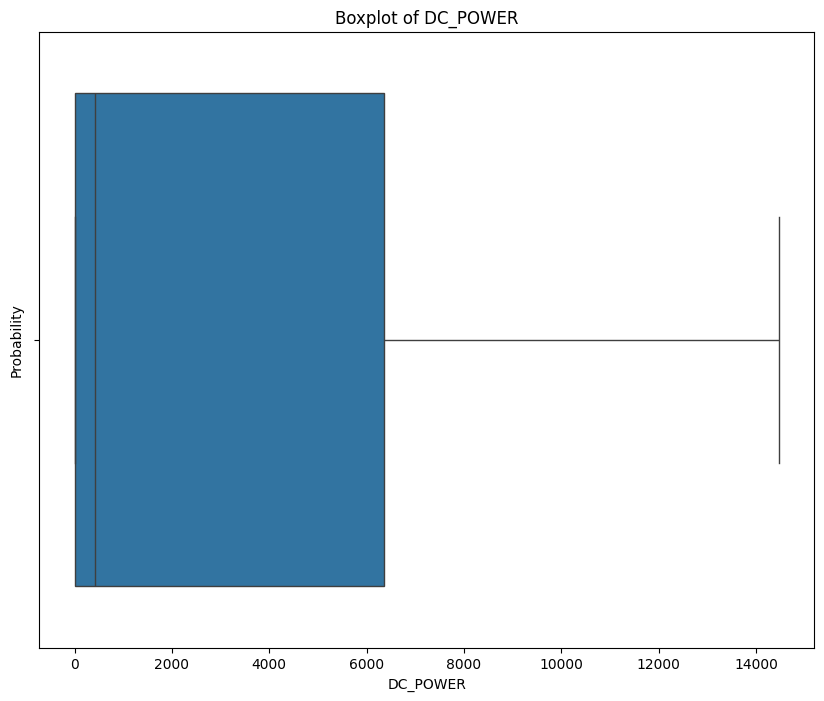

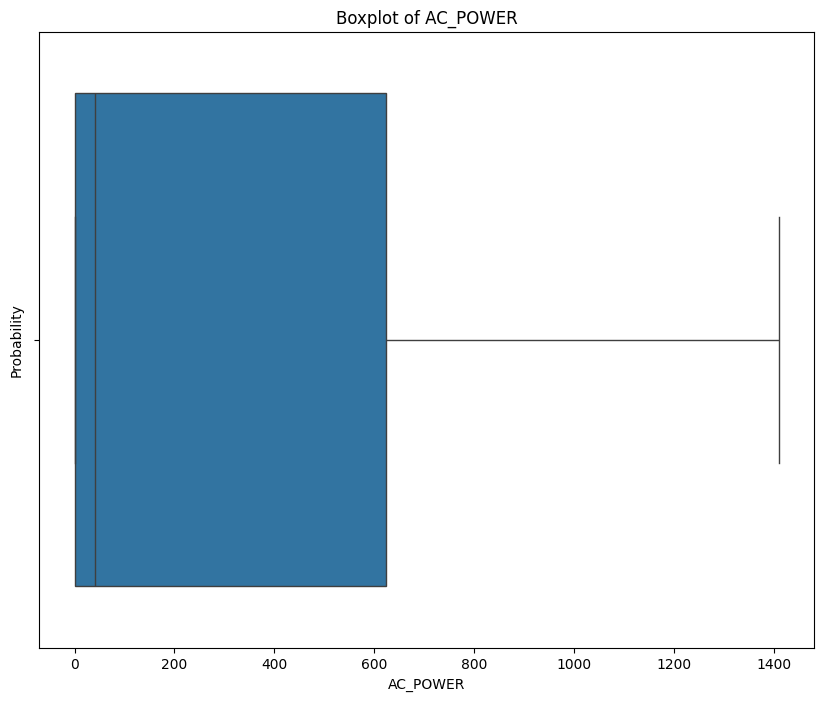

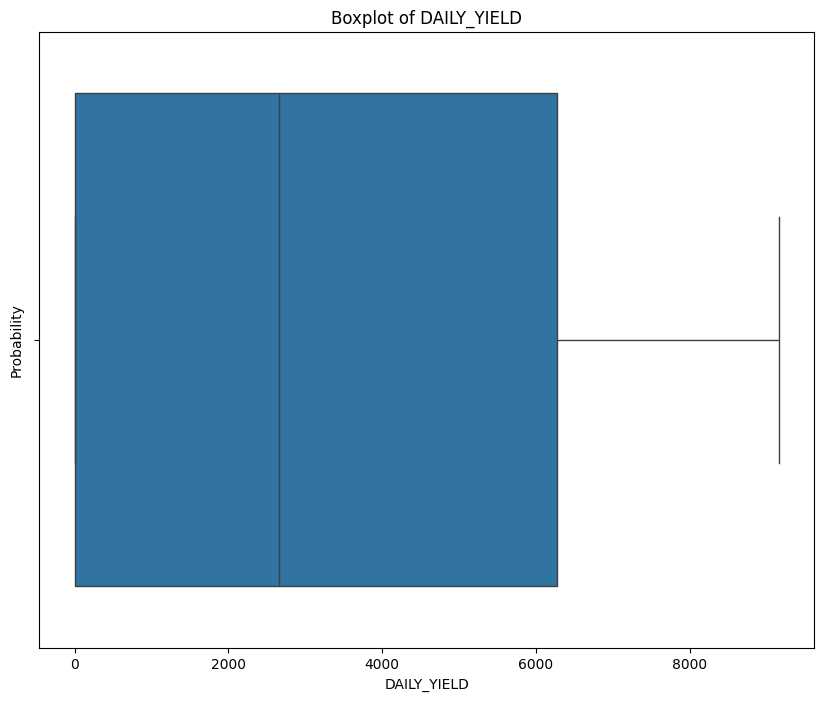

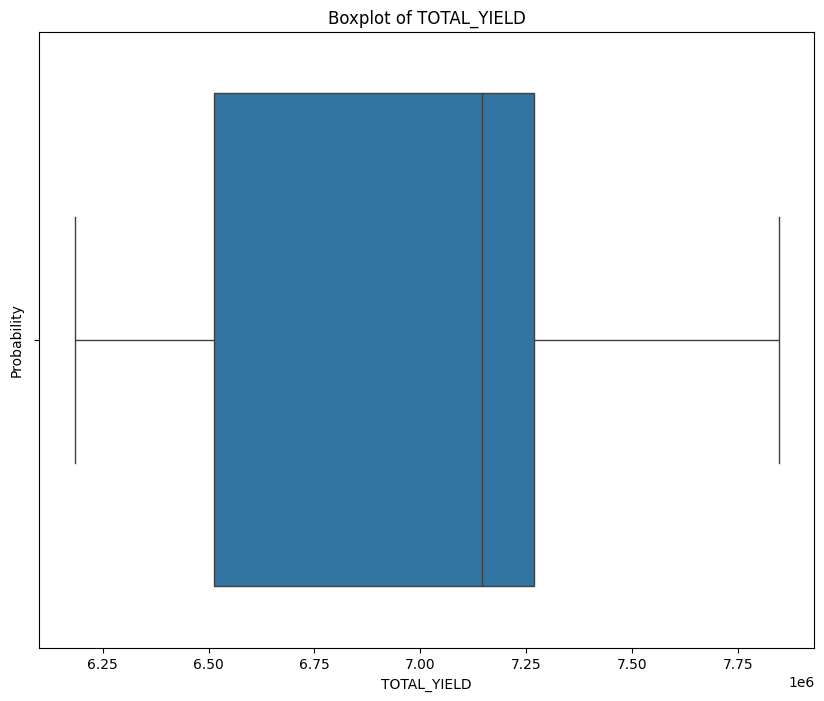

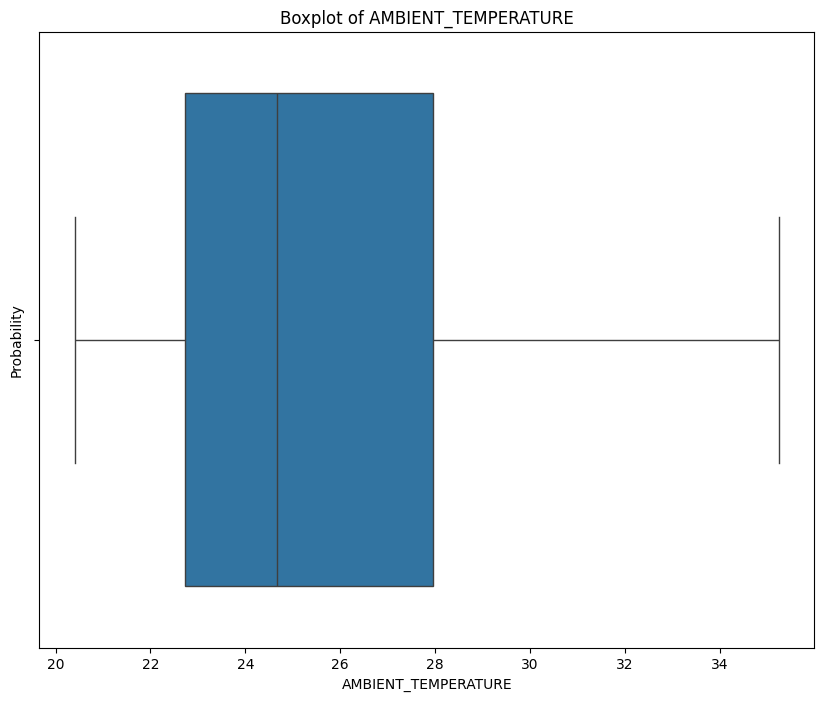

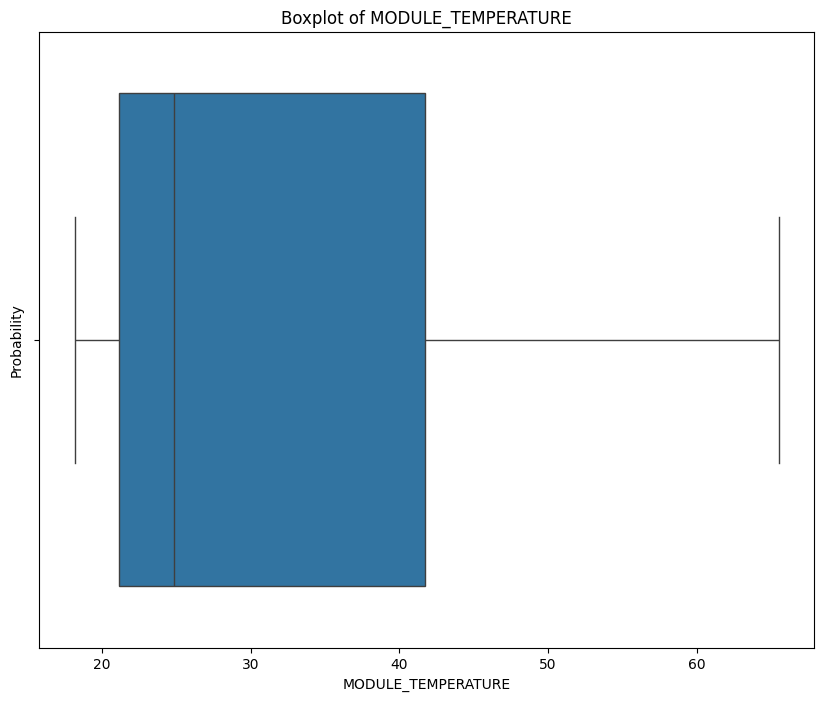

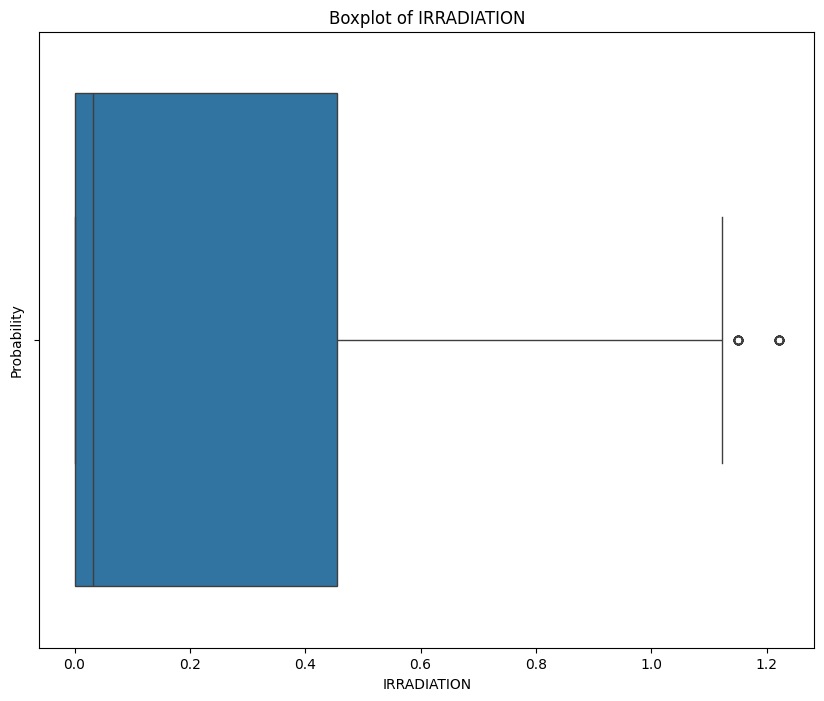

In [101]:
#boxplot

features = comb_data.select_dtypes(include='number').copy()
for col in features.columns:
    plt.figure(figsize=(10,8))
    sns.boxplot(x = features[col])
    plt.xlabel(f'{col}')
    plt.ylabel('Probability')
    plt.title(f'Boxplot of {col}')
    plt.show()

Outliers handling

IRRADIATION before IQR shape: (68774, 9), After IQR Shape: (68730, 9)


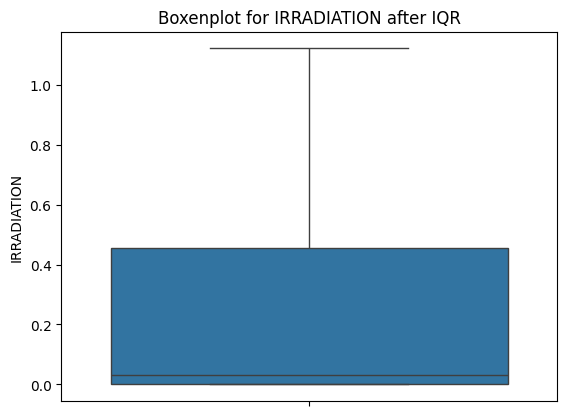

In [102]:
#IQR Implementation

iqr = comb_data['IRRADIATION'].quantile(0.75) - comb_data['IRRADIATION'].quantile(0.25)
lower_limit = comb_data['IRRADIATION'].quantile(0.25) - (iqr * 1.5)
upper_limit = comb_data['IRRADIATION'].quantile(0.75) + (iqr * 1.5)

outlier_data = (comb_data['IRRADIATION'] > upper_limit) | (comb_data['IRRADIATION'] < lower_limit)
df_trimmed = comb_data.loc[~outlier_data]

print(f'{col} before IQR shape: {comb_data.shape}, After IQR Shape: {df_trimmed.shape}')

sns.boxplot(y=df_trimmed[col])
plt.title(f'Boxenplot for {col} after IQR')
plt.show()

In [103]:
comb_data = df_trimmed

Data is good, no need to apply any outlier treatment techniques

In [104]:
comb_data.isnull().sum()

DATE_TIME              0
SOURCE_KEY             0
DC_POWER               0
AC_POWER               0
DAILY_YIELD            0
TOTAL_YIELD            0
AMBIENT_TEMPERATURE    0
MODULE_TEMPERATURE     0
IRRADIATION            0
dtype: int64

In [105]:
comb_data['AC_POWER'].max(),comb_data['AC_POWER'].min()# checking the 'AC_POWER' feature min and max vallues

(np.float64(1405.3), np.float64(0.0))

In [106]:
comb_data['DC_POWER'].max(),comb_data['DC_POWER'].min() # checking the 'DC_POWER' feature min and max vallues

(np.float64(14413.42857), np.float64(0.0))

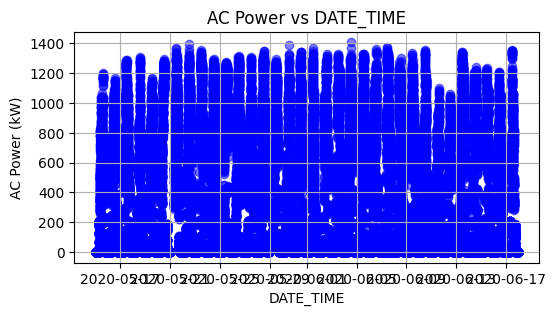

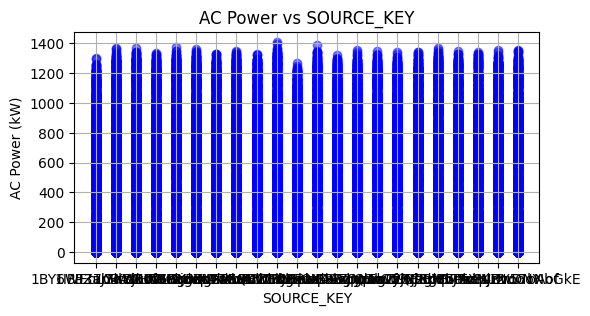

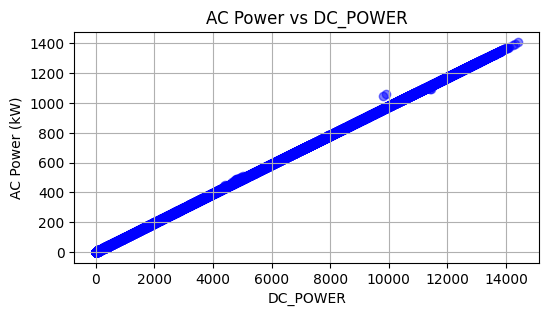

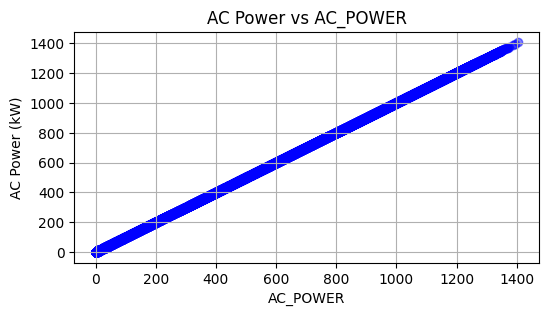

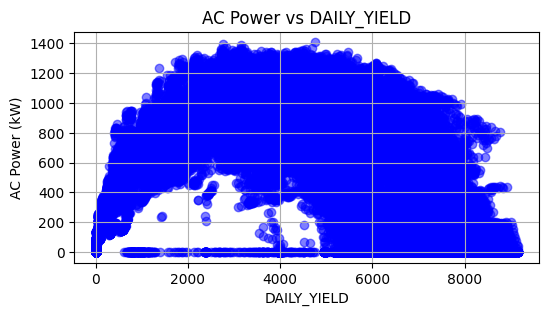

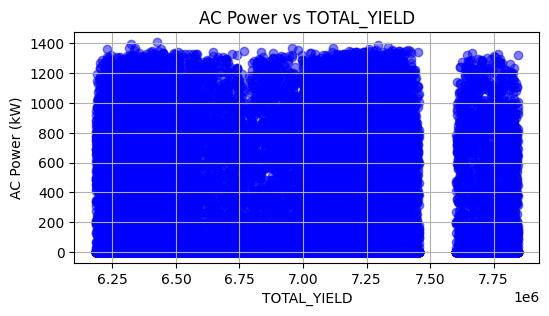

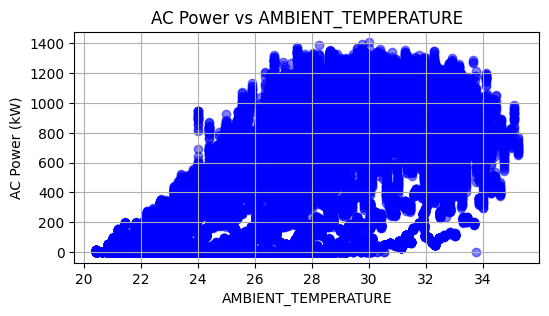

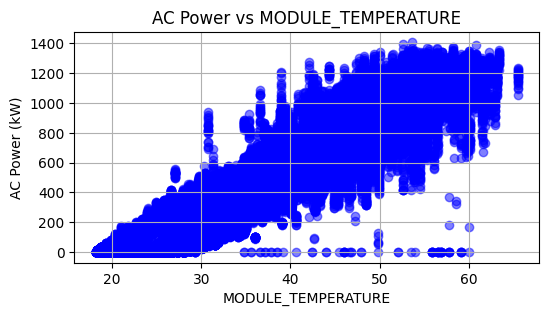

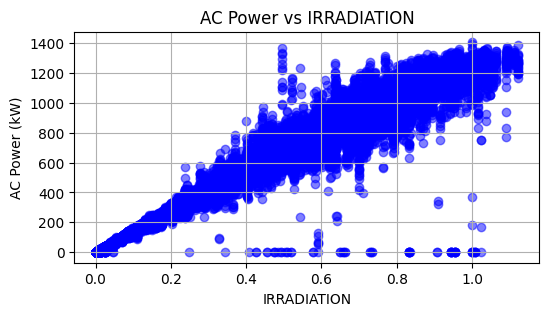

In [107]:
# Join the feature columns and target into one DataFrame to ensure alignment
plot_df = comb_data.copy()
plot_df['AC_POWER'] = comb_data['AC_POWER']

# Now loop through and plot
for col in comb_data.columns:
    plt.figure(figsize=(6, 3))
    plt.scatter(x=plot_df[col], y=plot_df['AC_POWER'], alpha=0.5, c='blue')
    plt.xlabel(f'{col}')
    plt.ylabel('AC Power (kW)')
    plt.title(f'AC Power vs {col}')
    plt.grid(True)
    plt.show()

### Scatter Plot Summary: AC Power vs Key Features

Each scatter plot below visualizes the relationship between **AC Power** (target variable) and different sensor or performance-related features from the solar plant data.


#### 1. AC Power vs **DC_POWER**
- **Relationship**: Strong **linear** correlation.
- **Insight**: As `DC_POWER` increases, `AC Power` increases proportionally.


#### 2. AC Power vs **DAILY_YIELD**
- **Relationship**: **Bell-shaped** curve.
- **Insight**: AC power increases with daily yield to a point, then declines.


#### 3. AC Power vs **TOTAL_YIELD**
- **Relationship**: **No direct** linear correlation.
- **Insight**: Total yield accumulates over time and doesn’t track instantaneous power.



#### 4. AC Power vs **AMBIENT_TEMPERATURE**
- **Relationship**: Moderate **non-linear** trend.
- **Insight**: AC power increases with temperature up to ~29–30°C, then declines.

#### 5. AC Power vs **MODULE_TEMPERATURE**
- **Relationship**: **Positive** correlation with some outliers.
- **Insight**: Higher module temperatures generally increase power output but have limits.


#### 6. AC Power vs **IRRADIATION**
- **Relationship**: **Strong linear** correlation.
- **Insight**: Higher solar radiation (irradiation) leads to higher AC power.


#### Key Observations:
- `DC_POWER` and `IRRADIATION` show the **strongest correlation** with `AC Power`.
- `DAILY_YIELD` and `AMBIENT_TEMPERATURE` show **non-linear patterns**.
- `TOTAL_YIELD` is **not useful** for real-time power prediction.
- There may be some **outliers** or faulty readings in `MODULE_TEMPERATURE`.



In [108]:
comb_data['DATE_TIME'] = pd.to_datetime(comb_data['DATE_TIME'])

# Extract date and time components
comb_data['DATE'] = comb_data['DATE_TIME'].dt.date
comb_data['YEAR'] = comb_data['DATE_TIME'].dt.year
comb_data['MONTH'] = comb_data['DATE_TIME'].dt.month
comb_data['DAY'] = comb_data['DATE_TIME'].dt.day
comb_data['HOUR'] = comb_data['DATE_TIME'].dt.hour
comb_data['MINUTE'] = comb_data['DATE_TIME'].dt.minute
comb_data['SECOND'] = comb_data['DATE_TIME'].dt.second

# Time-based features
comb_data['DAY_OF_WEEK'] = comb_data['DATE_TIME'].dt.dayofweek  # Monday=0, Sunday=6

# Time of day categories
comb_data['TIME_OF_DAY'] = pd.cut(comb_data['HOUR'],
                                 bins=[0,6,12,18,24],
                                 labels=['Night','Morning','Afternoon','Evening'],
                                 include_lowest=True,
                                 right=False)


Focuses on extracting and creating new features from the DATE_TIME column to capture various temporal aspects, which are often crucial for time-series analysis and predictive modeling.

In [109]:
comb_data #checking the data

,DATE_TIME,SOURCE_KEY,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION,DATE,YEAR,MONTH,DAY,HOUR,MINUTE,SECOND,DAY_OF_WEEK,TIME_OF_DAY
0,2020-05-15 00:00:00,1BY6WEcLGh8j5v7,0.0,0.0,0.000,6259559.0,25.184316,22.857507,0.0,2020-05-15,2020,5,15,0,0,0,4,Night
1,2020-05-15 00:00:00,1IF53ai7Xc0U56Y,0.0,0.0,0.000,6183645.0,25.184316,22.857507,0.0,2020-05-15,2020,5,15,0,0,0,4,Night
2,2020-05-15 00:00:00,3PZuoBAID5Wc2HD,0.0,0.0,0.000,6987759.0,25.184316,22.857507,0.0,2020-05-15,2020,5,15,0,0,0,4,Night
3,2020-05-15 00:00:00,7JYdWkrLSPkdwr4,0.0,0.0,0.000,7602960.0,25.184316,22.857507,0.0,2020-05-15,2020,5,15,0,0,0,4,Night
4,2020-05-15 00:00:00,McdE0feGgRqW7Ca,0.0,0.0,0.000,7158964.0,25.184316,22.857507,0.0,2020-05-15,2020,5,15,0,0,0,4,Night
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68769,2020-06-17 23:45:00,uHbuxQJl8lW7ozc,0.0,0.0,5967.000,7287002.0,21.909288,20.427972,0.0,2020-06-17,2020,6,17,23,45,0,2,Evening
68770,2020-06-17 23:45:00,wCURE6d3bPkepu2,0.0,0.0,5147.625,7028601.0,21.909288,20.427972,0.0,2020-06-17,2020,6,17,23,45,0,2,Evening
68771,2020-06-17 23:45:00,z9Y9gH1T5YWrNuG,0.0,0.0,5819.000,7251204.0,21.909288,20.427972,0.0,2020-06-17,2020,6,17,23,45,0,2,Evening
68772,2020-06-17 23:45:00,zBIq5rxdHJRwDNY,0.0,0.0,5817.000,6583369.0,21.909288,20.427972,0.0,2020-06-17,2020,6,17,23,45,0,2,Evening


In [110]:
comb_data.isnull().sum()

DATE_TIME              0
SOURCE_KEY             0
DC_POWER               0
AC_POWER               0
DAILY_YIELD            0
TOTAL_YIELD            0
AMBIENT_TEMPERATURE    0
MODULE_TEMPERATURE     0
IRRADIATION            0
DATE                   0
YEAR                   0
MONTH                  0
DAY                    0
HOUR                   0
MINUTE                 0
SECOND                 0
DAY_OF_WEEK            0
TIME_OF_DAY            0
dtype: int64

# Data Visualization:

<Figure size 1000x600 with 0 Axes>

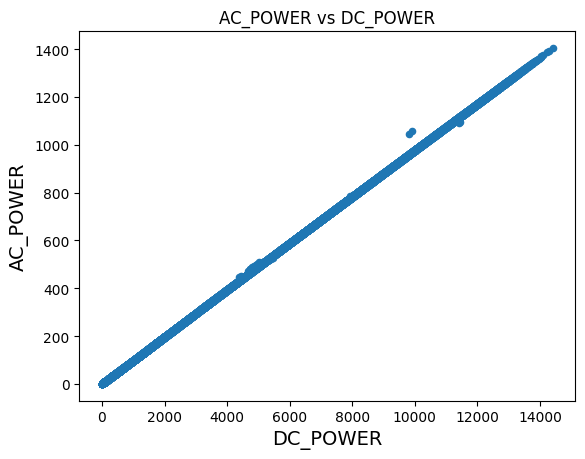

<Figure size 1000x600 with 0 Axes>

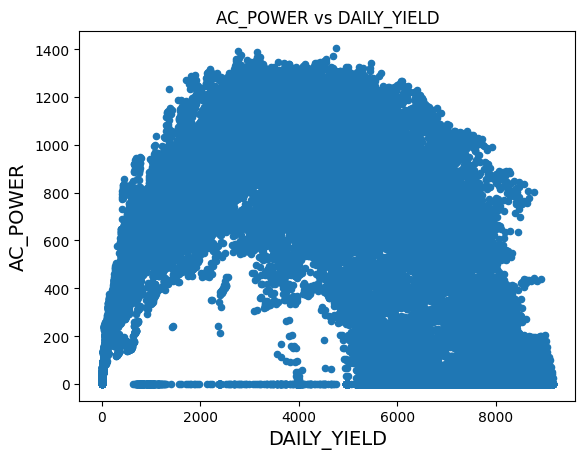

<Figure size 1000x600 with 0 Axes>

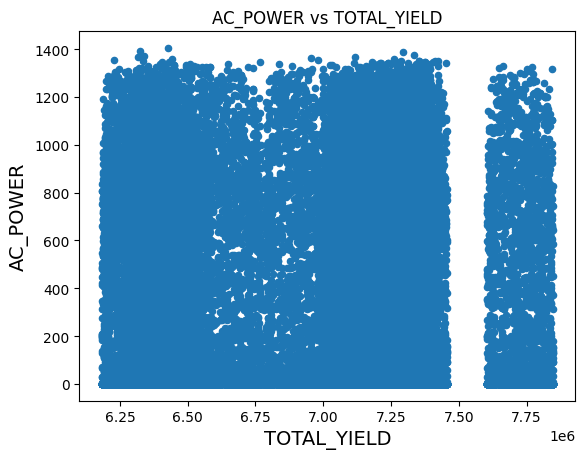

<Figure size 1000x600 with 0 Axes>

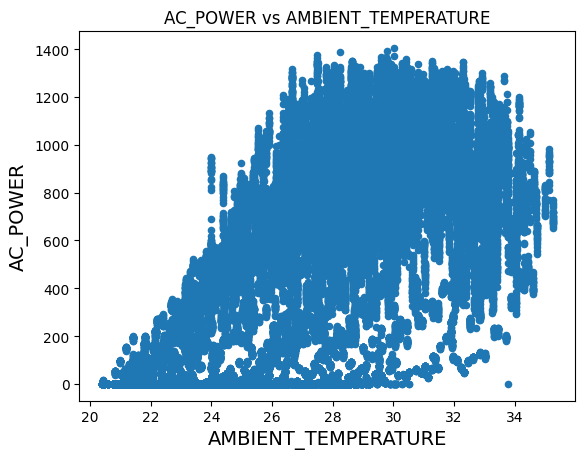

<Figure size 1000x600 with 0 Axes>

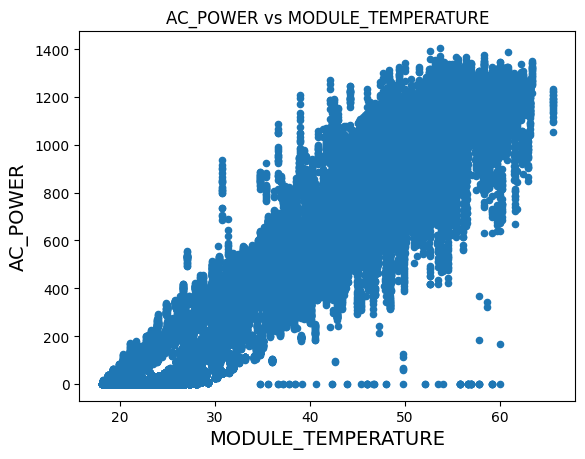

<Figure size 1000x600 with 0 Axes>

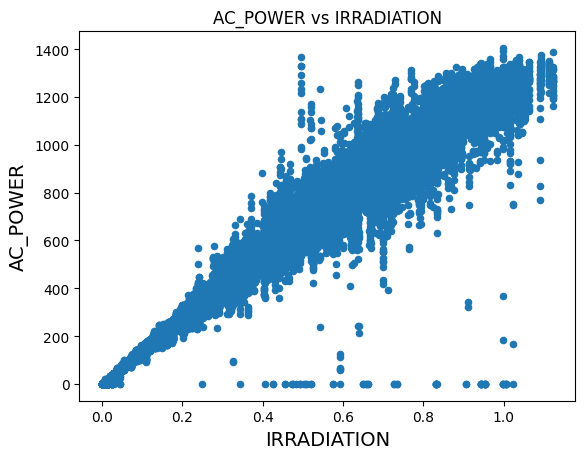

<Figure size 1000x600 with 0 Axes>

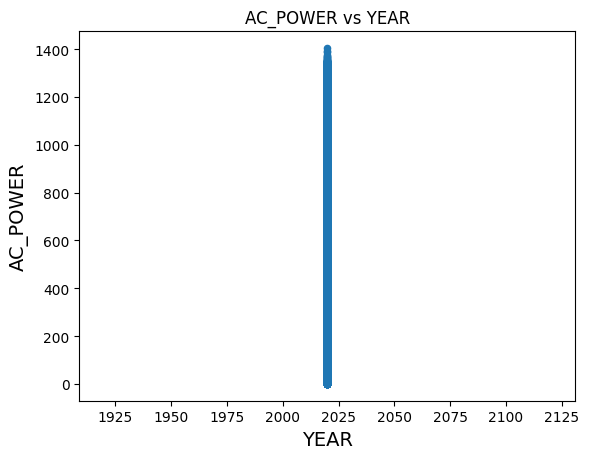

<Figure size 1000x600 with 0 Axes>

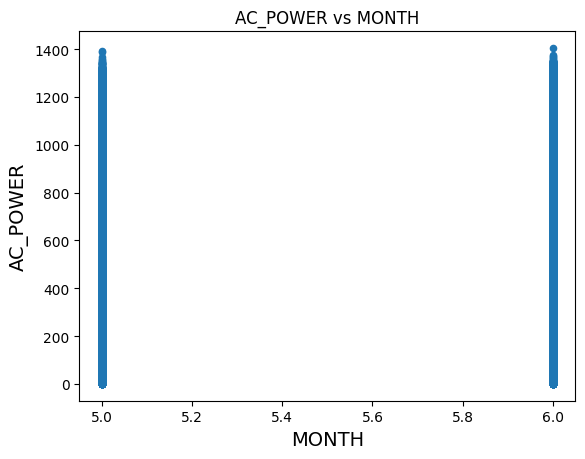

<Figure size 1000x600 with 0 Axes>

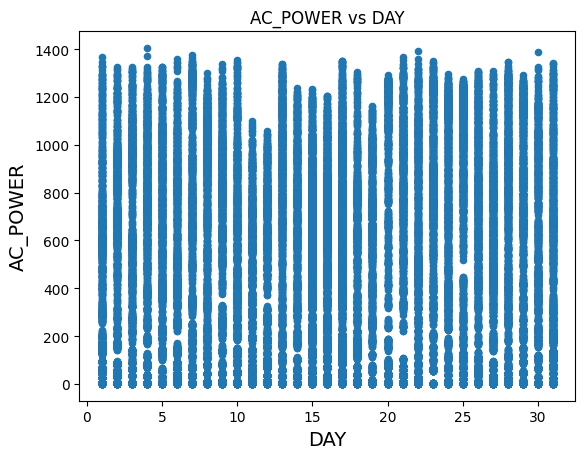

<Figure size 1000x600 with 0 Axes>

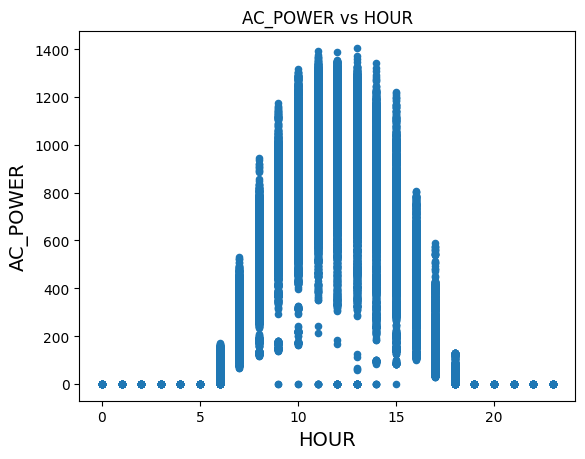

<Figure size 1000x600 with 0 Axes>

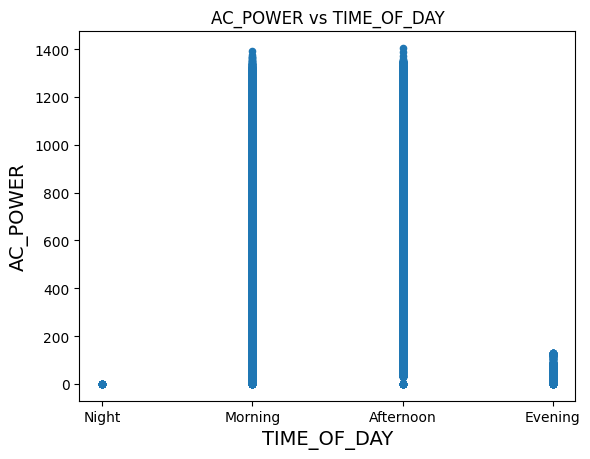

In [111]:

COL = ['DC_POWER', 'DAILY_YIELD','TOTAL_YIELD','AMBIENT_TEMPERATURE','MODULE_TEMPERATURE','IRRADIATION','YEAR','MONTH',	'DAY','HOUR','TIME_OF_DAY']

for i in COL:
  plt.figure(figsize=(10,6))
  comb_data.plot.scatter(x=i, y = 'AC_POWER')
  plt.xlabel(f'{i}', fontsize=14)
  plt.ylabel('AC_POWER', fontsize=14)
  plt.title(f'AC_POWER vs {i}')
  plt.show()

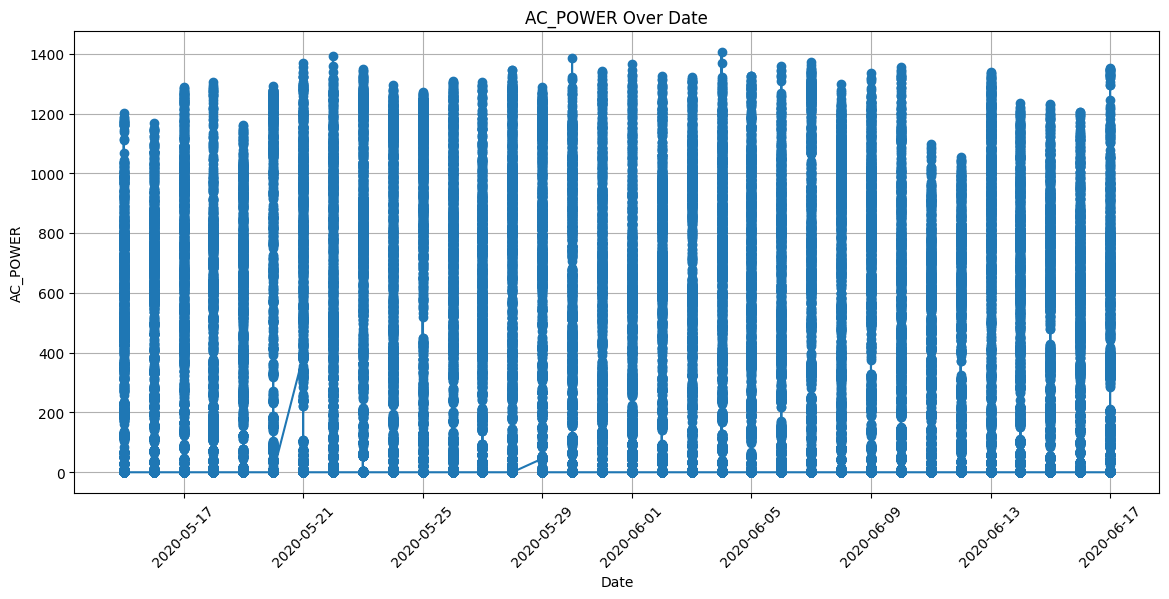

In [112]:
plt.figure(figsize=(14,6))
plt.plot(comb_data['DATE'], comb_data['AC_POWER'], marker='o')
plt.title('AC_POWER Over Date')
plt.xlabel('Date')
plt.ylabel('AC_POWER')
plt.grid(True)
plt.xticks(rotation=45)
plt.show()

The plot shows fluctuations in AC power over the month of June 2020. There are notable peaks and dips, indicating varying energy generation on different days.

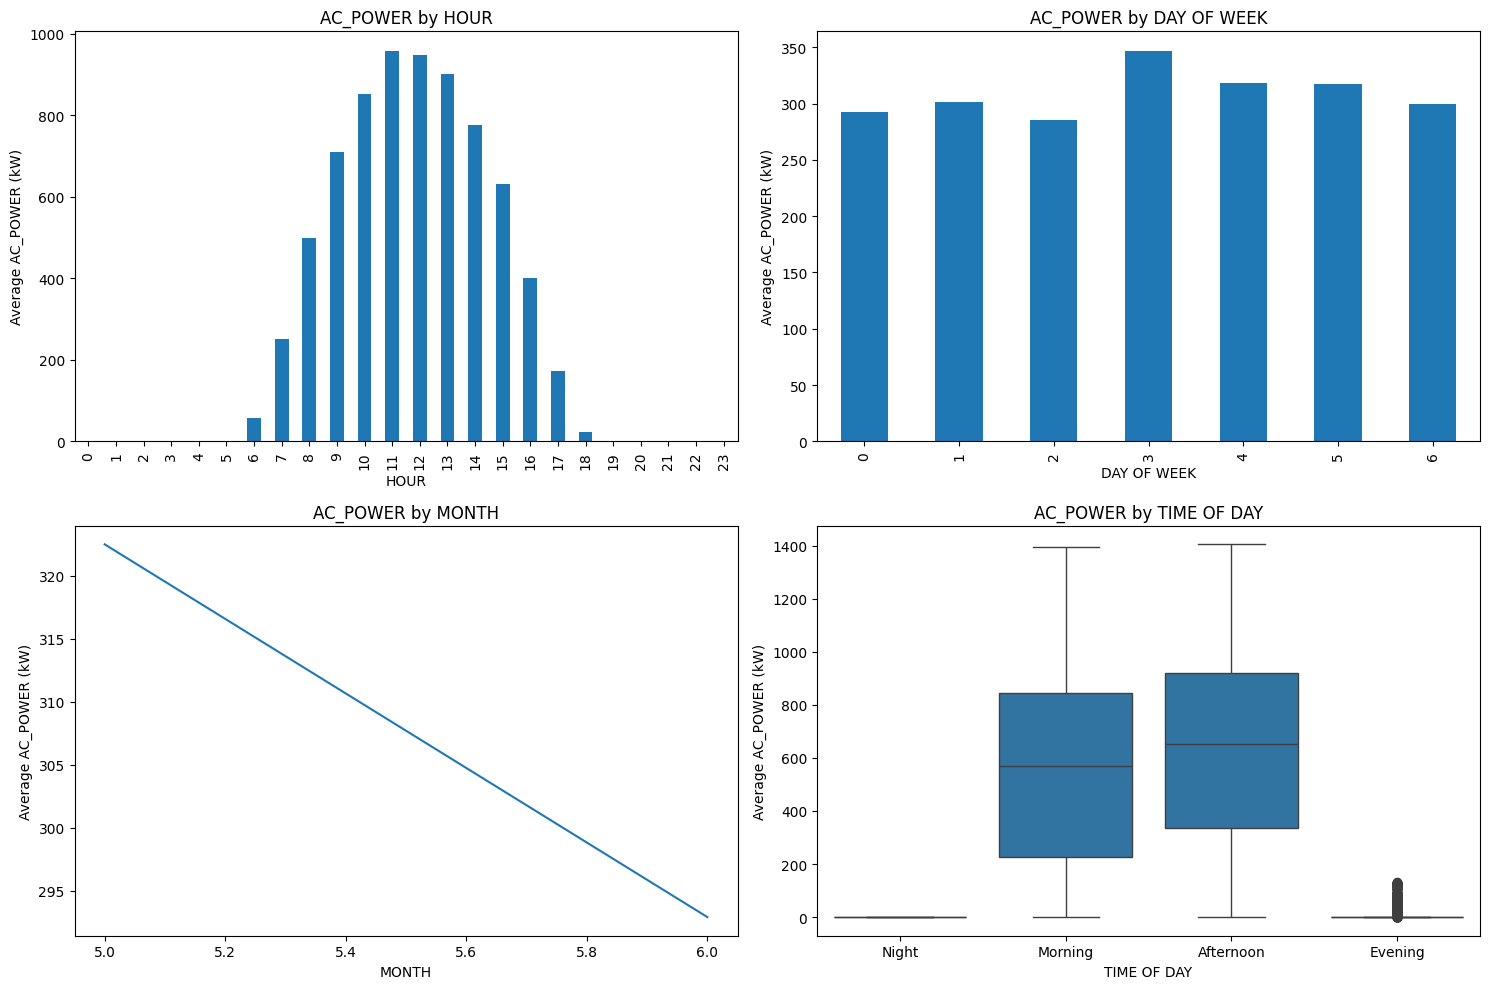

In [113]:
# List of time aggregations to visualize
time_units = ['HOUR', 'DAY_OF_WEEK', 'MONTH', 'TIME_OF_DAY']

plt.figure(figsize=(15, 10))
for i, time_unit in enumerate(time_units, 1):
    plt.subplot(2, 2, i)

    if time_unit == 'TIME_OF_DAY':
        sns.boxplot(x=time_unit, y='AC_POWER', data=comb_data)
    else:
        comb_data.groupby(time_unit)['AC_POWER'].mean().plot(kind='bar' if time_unit in ['HOUR', 'DAY_OF_WEEK'] else 'line')

    plt.title(f'AC_POWER by {time_unit.replace("_", " ")}')
    plt.ylabel('Average AC_POWER (kW)')
    plt.xlabel(time_unit.replace("_", " "))

plt.tight_layout()
plt.show()

These plots provide valuable insights into the patterns of solar energy generation throughout different periods of the day, week, and month.

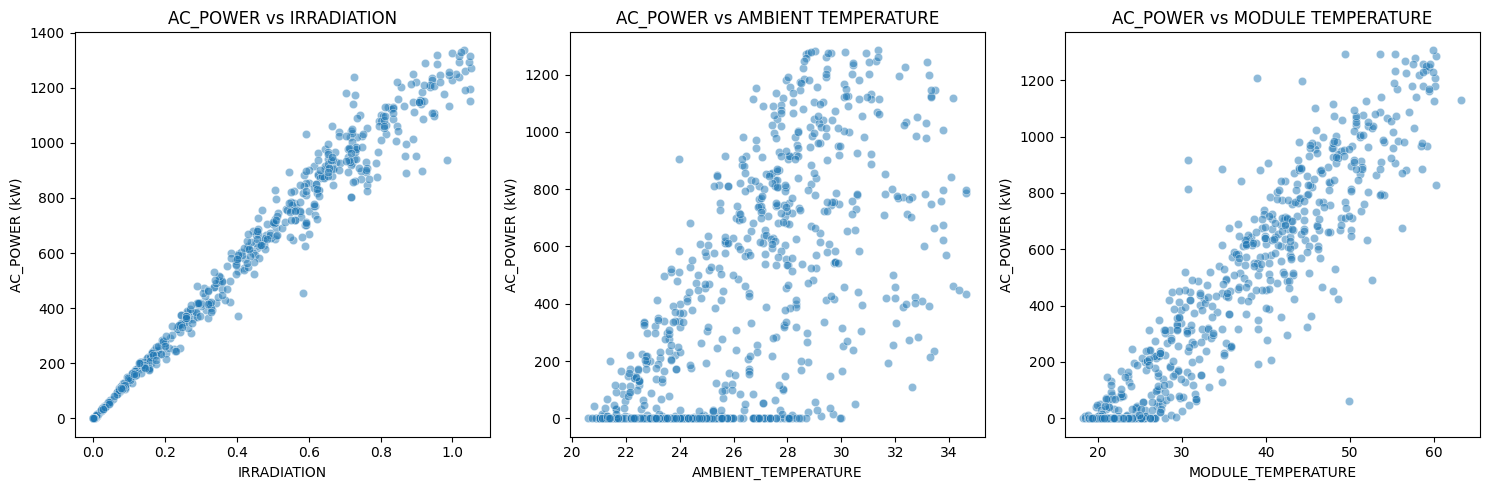

In [114]:
weather_features = ['IRRADIATION', 'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE']

plt.figure(figsize=(15, 5))
for i, feature in enumerate(weather_features, 1):
    plt.subplot(1, 3, i)
    sns.scatterplot(x=feature, y='AC_POWER', data=comb_data.sample(1000), alpha=0.5)
    plt.title(f'AC_POWER vs {feature.replace("_", " ")}')
    plt.ylabel('AC_POWER (kW)')

plt.tight_layout()
plt.show()

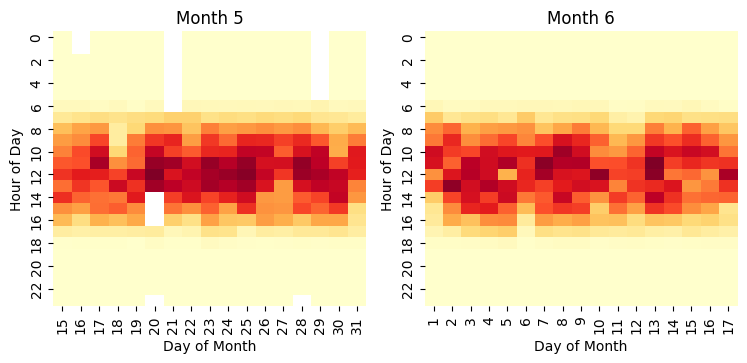

In [115]:
# Create heatmap data for each month
months = comb_data['MONTH'].unique()

plt.figure(figsize=(15, 10))
for i, month in enumerate(sorted(months), 1):
    month_data = comb_data[comb_data['MONTH'] == month]
    heatmap_data = month_data.pivot_table(index='HOUR', columns='DAY', values='AC_POWER', aggfunc='mean')

    plt.subplot(3, 4, i)
    sns.heatmap(heatmap_data, cmap='YlOrRd', cbar=False)
    plt.title(f'Month {month}')
    plt.xlabel('Day of Month')
    plt.ylabel('Hour of Day')

plt.tight_layout()
plt.show()

- This graph tracks a metric (likely energy or temperature) over time:

        Hourly: Values drop at night, peak midday.

        Monthly (May & June): Higher in June, suggesting seasonal increase.

        Daily: Fluctuates slightly day-to-day.

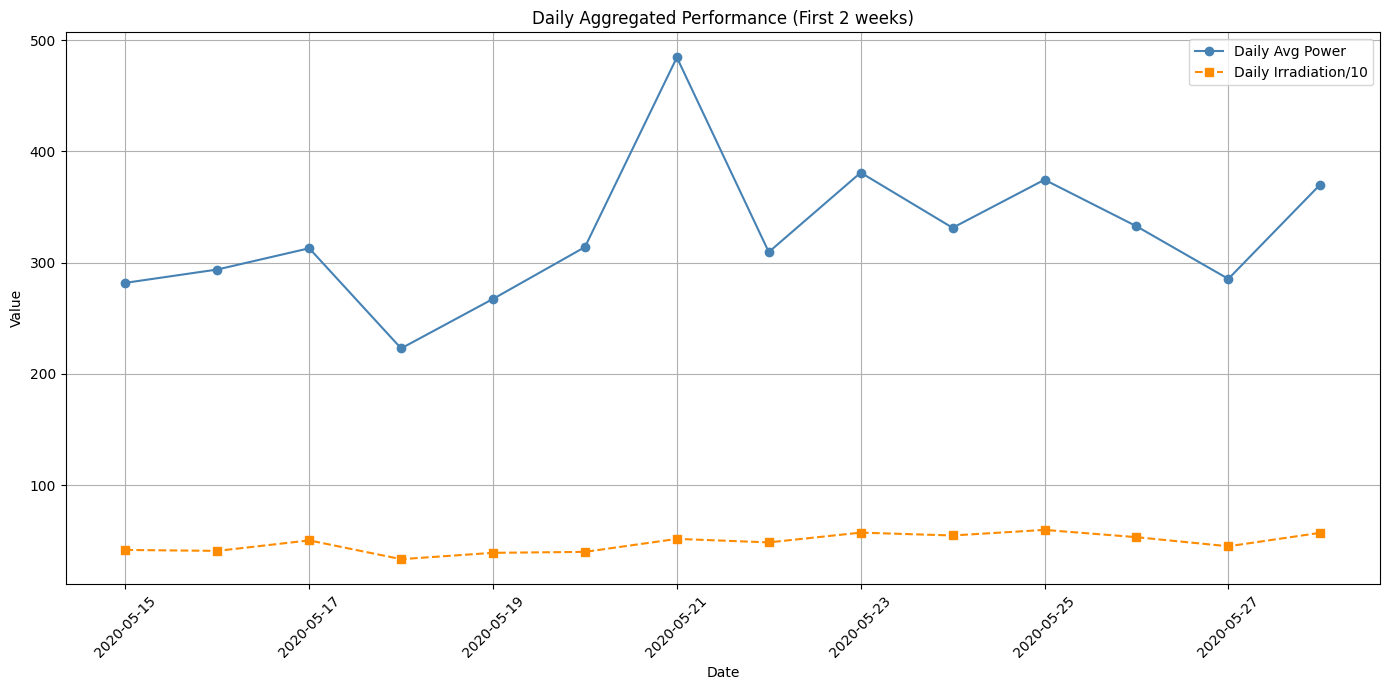

In [116]:
# Create daily aggregates
daily_data = comb_data.groupby(pd.Grouper(key='DATE_TIME', freq='D')).agg({
    'AC_POWER': 'mean',
    'IRRADIATION': 'sum',
    'MODULE_TEMPERATURE': 'max'
}).reset_index()

# Plot
plt.figure(figsize=(14, 7))
plt.plot(daily_data['DATE_TIME'][:14], daily_data['AC_POWER'][:14],
         marker='o', linestyle='-', color='steelblue', label='Daily Avg Power')
plt.plot(daily_data['DATE_TIME'][:14], daily_data['IRRADIATION'][:14]/10,
         marker='s', linestyle='--', color='darkorange', label='Daily Irradiation/10')

plt.title('Daily Aggregated Performance (First 2 weeks)')
plt.ylabel('Value')
plt.xlabel('Date')
plt.grid(True)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Graph shows solar power and irradiation trends over two weeks, peaking around May 21. Values fluctuate daily, suggesting weather impacts.

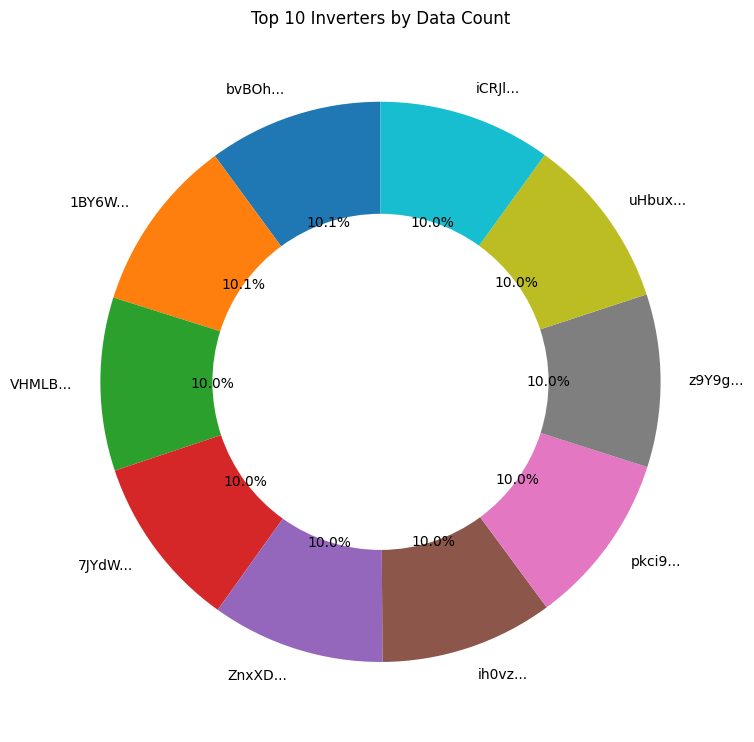

In [117]:
# Get the top 10 inverters by count
top_inverters = comb_data['SOURCE_KEY'].value_counts().nlargest(10)

plt.figure(figsize=(15, 10))

# Pie Chart 1: Simple distribution
plt.subplot(1, 2, 1)
plt.pie(top_inverters,
        labels=[f"{inv[:5]}..." for inv in top_inverters.index],
        autopct='%1.1f%%',
        startangle=90,
        wedgeprops={'width': 0.4})
plt.title('Top 10 Inverters by Data Count')

plt.tight_layout()
plt.show()

In [118]:

from scipy.stats import f_oneway

# ANOVA: Does DC_POWER differ significantly across SOURCE_KEYs?
groups = [group['AC_POWER'].values for name, group in df_plant_1_gen.groupby('SOURCE_KEY')]
f_stat, p_val = f_oneway(*groups)
print(f"ANOVA Test on AC_POWER by SOURCE_KEY -> F-statistic: {f_stat:.4f}, p-value: {p_val:.4f}")

ANOVA Test on AC_POWER by SOURCE_KEY -> F-statistic: 2.0543, p-value: 0.0030


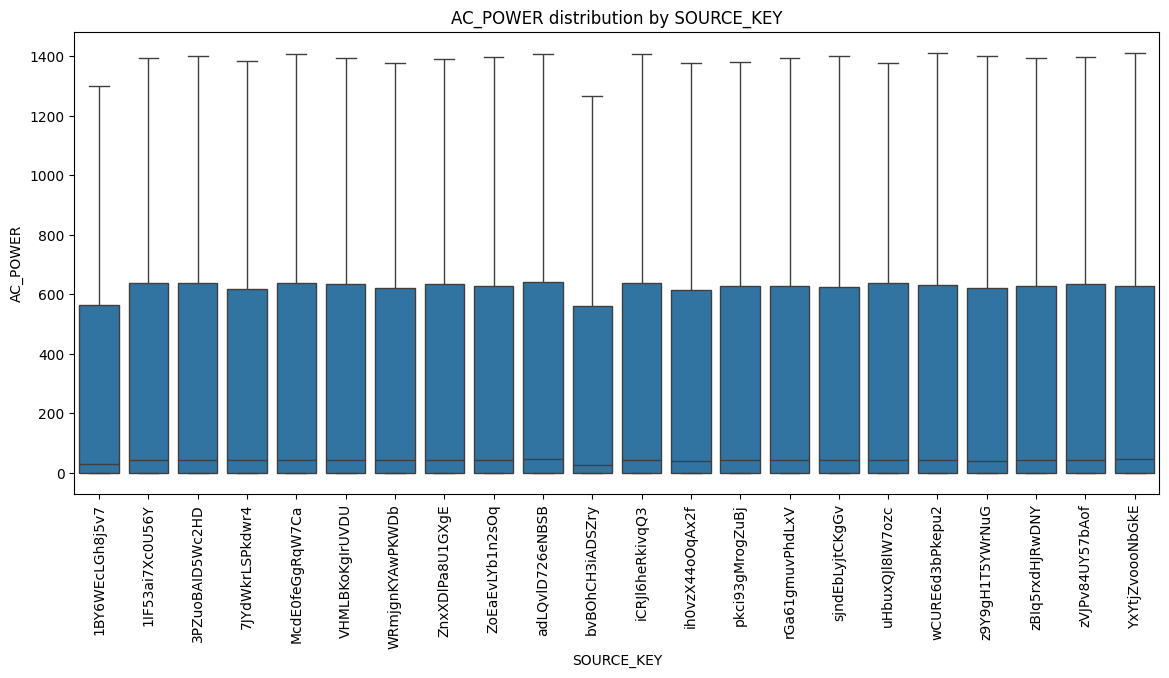

In [119]:
plt.figure(figsize=(14, 6))
sns.boxplot(x='SOURCE_KEY', y='AC_POWER', data=df_plant_1_gen)
plt.xticks(rotation=90)
plt.title('AC_POWER distribution by SOURCE_KEY')
plt.show()

### Summary

| **Metric**     | **Value** | **Meaning**                                      |
|----------------|-----------|--------------------------------------------------|
| **F-statistic**| 2.0543    | Moderate variability between groups vs. within groups |
| **p-value**    | 0.0030    | Significant (p < 0.05) — reject the null hypothesis |

---

### Conclusion:
There is a **statistically significant difference** in mean `AC_POWER` among at least one of the `SOURCE_KEY` groups.

## Data Transformation

In [120]:
# Label encoding technique we are using here to convert object data into numerical data

categorical_col1 = ['SOURCE_KEY']

# Initialize label encoder
encoding = LabelEncoder()

# Encode while preserving the index
encoding_df = pd.DataFrame(
    encoding.fit_transform(comb_data['SOURCE_KEY']),
    index=comb_data.index,
    columns=['SOURCE_KEY']
)

# Drop original column and concatenate encoded
comb_data = comb_data.drop(['SOURCE_KEY'], axis=1)
comb_data = pd.concat([comb_data, encoding_df], axis=1)

comb_data.head(2)

,DATE_TIME,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION,DATE,YEAR,MONTH,DAY,HOUR,MINUTE,SECOND,DAY_OF_WEEK,TIME_OF_DAY,SOURCE_KEY
0,2020-05-15,0.0,0.0,0.0,6259559.0,25.184316,22.857507,0.0,2020-05-15,2020,5,15,0,0,0,4,Night,0
1,2020-05-15,0.0,0.0,0.0,6183645.0,25.184316,22.857507,0.0,2020-05-15,2020,5,15,0,0,0,4,Night,1


In [121]:
categorical_col2 = ['TIME_OF_DAY']
encoding = LabelEncoder()

# Apply label encoding while preserving index and column name
encoding_df1 = pd.DataFrame(
    encoding.fit_transform(comb_data['TIME_OF_DAY']),
    index=comb_data.index,
    columns=['TIME_OF_DAY']
)

# Drop original column and add encoded one
comb_data = comb_data.drop(['TIME_OF_DAY'], axis=1)
comb_data = pd.concat([comb_data, encoding_df1], axis=1)



In [122]:
comb_data = comb_data.rename(columns={0: 'TIME_OF_DAY'})
comb_data.head(2)

,DATE_TIME,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION,DATE,YEAR,MONTH,DAY,HOUR,MINUTE,SECOND,DAY_OF_WEEK,SOURCE_KEY,TIME_OF_DAY
0,2020-05-15,0.0,0.0,0.0,6259559.0,25.184316,22.857507,0.0,2020-05-15,2020,5,15,0,0,0,4,0,3
1,2020-05-15,0.0,0.0,0.0,6183645.0,25.184316,22.857507,0.0,2020-05-15,2020,5,15,0,0,0,4,1,3


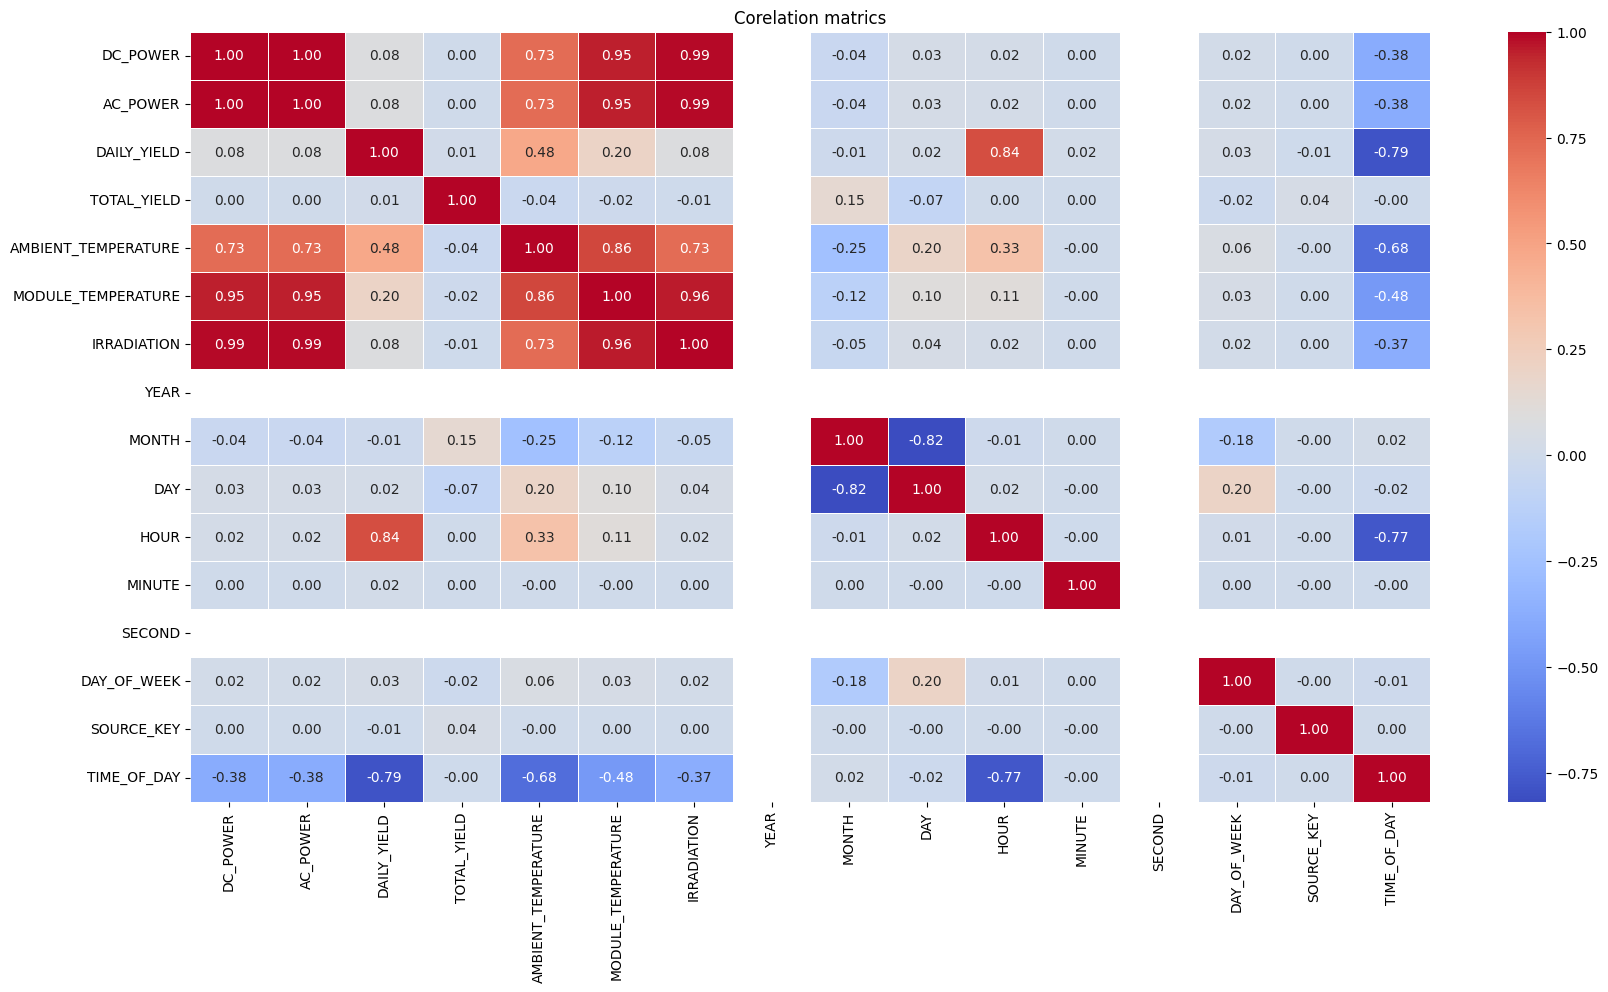

In [123]:
# checknig the correlation of features
feature = comb_data.copy()
features = feature.drop(['DATE_TIME','DATE'], axis=1).copy()
matrix_corr = features.corr()
plt.figure(figsize=(20,10))
sns.heatmap(matrix_corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Corelation matrics')
plt.show()

In [124]:

# Get correlation of all features with the target

correlation_with_target = features.corr()['AC_POWER'].abs()

threshold = 0.01

relevant_features = correlation_with_target[correlation_with_target >= threshold].index.tolist()

# Create new DataFrame with only relevant features
df_filtered = comb_data[relevant_features]

dropped = comb_data.shape[1] - df_filtered.shape[1]
print(f"Dropped {dropped} features with correlation < {threshold}")
print("Remaining features:", df_filtered.columns.tolist())

Dropped 7 features with correlation < 0.01
Remaining features: ['DC_POWER', 'AC_POWER', 'DAILY_YIELD', 'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION', 'MONTH', 'DAY', 'HOUR', 'DAY_OF_WEEK', 'TIME_OF_DAY']


In [125]:
df_filtered.head(3)

,DC_POWER,AC_POWER,DAILY_YIELD,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION,MONTH,DAY,HOUR,DAY_OF_WEEK,TIME_OF_DAY
0,0.0,0.0,0.0,25.184316,22.857507,0.0,5,15,0,4,3
1,0.0,0.0,0.0,25.184316,22.857507,0.0,5,15,0,4,3
2,0.0,0.0,0.0,25.184316,22.857507,0.0,5,15,0,4,3


In [126]:
from scipy.stats import pearsonr
import numpy as np

print("Significance of correlation with AC_POWER:")

for col in comb_data.drop(columns=['AC_POWER', 'DATE_TIME']).select_dtypes(include='number').columns:
    x = comb_data[col].values
    y = comb_data['AC_POWER'].values

    # Skip constant columns
    if np.std(x) == 0:
        print(f"{col}: Skipped (constant input)")
        continue

    try:
        corr, p_val = pearsonr(x, y)
        print(f"{col}: Correlation = {corr:.3f}, p-value = {p_val:.4f}")
    except Exception as e:
        print(f"{col}: Error -> {e}")

Significance of correlation with AC_POWER:
DC_POWER: Correlation = 1.000, p-value = 0.0000
DAILY_YIELD: Correlation = 0.082, p-value = 0.0000
TOTAL_YIELD: Correlation = 0.004, p-value = 0.3537
AMBIENT_TEMPERATURE: Correlation = 0.726, p-value = 0.0000
MODULE_TEMPERATURE: Correlation = 0.955, p-value = 0.0000
IRRADIATION: Correlation = 0.990, p-value = 0.0000
YEAR: Skipped (constant input)
MONTH: Correlation = -0.038, p-value = 0.0000
DAY: Correlation = 0.032, p-value = 0.0000
HOUR: Correlation = 0.024, p-value = 0.0000
MINUTE: Correlation = 0.003, p-value = 0.3846
SECOND: Skipped (constant input)
DAY_OF_WEEK: Correlation = 0.016, p-value = 0.0000
SOURCE_KEY: Correlation = 0.002, p-value = 0.5655
TIME_OF_DAY: Correlation = -0.382, p-value = 0.0000


### 📊 Pearson Correlation Results with `AC_POWER`

| **Feature**           | **Correlation** | **p-value** | **Interpretation** |
|-----------------------|------------------|-------------|---------------------|
| `DC_POWER`            | 1.000            | 0.0000      | Perfect positive correlation. `AC_POWER` and `DC_POWER` are linearly dependent. Likely used to compute each other. |
| `DAILY_YIELD`         | 0.082            | 0.0000      | Very weak positive correlation, but statistically significant (large dataset makes even small effects significant). |
| `TOTAL_YIELD`         | 0.004            | 0.3139      | No meaningful correlation. Also, **not significant** (p > 0.05). |
| `AMBIENT_TEMPERATURE` | 0.725            | 0.0000      | Strong positive correlation. Higher ambient temperature → more `AC_POWER`. |
| `MODULE_TEMPERATURE`  | 0.955            | 0.0000      | Very strong positive correlation. Likely physically related. |
| `IRRADIATION`         | 0.989            | 0.0000      | Near-perfect positive correlation. As expected, more sunlight → more power. |
| `YEAR`                | Skipped          | -           | Column has constant value → correlation undefined. |
| `MONTH`               | -0.038           | 0.0000      | Very weak **negative** correlation, but statistically significant due to data size. |
| `DAY`                 | 0.033            | 0.0000      | Very weak positive correlation, but significant. Not practically useful. |
| `HOUR`                | 0.024            | 0.0000      | Very weak positive correlation. Might reflect sunlight hour trends. |
| `MINUTE`              | 0.001            | 0.7619      | No correlation. Also **not significant**. Likely noise. |
| `SECOND`              | Skipped          | -           | Constant input. No variation. |
| `DAY_OF_WEEK`         | 0.018            | 0.0000      | Very weak effect, but statistically significant. Likely not important practically. |
| `SOURCE_KEY`          | 0.002            | 0.5504      | No meaningful correlation. Also **not significant**. Can likely be excluded as a numerical feature. |
| `TIME_OF_DAY`         | -0.383           | 0.0000      | Moderate **negative** correlation. As time increases (e.g., past peak sunlight), `AC_POWER` decreases. |


After identifying the irrelevant or uninformative features, the next step is to ignore or drop them before feeding the data into model.

In [127]:
columns_to_drop = ['TOTAL_YIELD', 'MINUTE', 'SECOND', 'YEAR','SOURCE_KEY', 0]  # 0 is the buggy column name

# Drop if present in dataset
for col in columns_to_drop:
    if col in comb_data.columns:
        comb_data = comb_data.drop(columns=[col])

In [128]:
comb_data.head(3)

,DATE_TIME,DC_POWER,AC_POWER,DAILY_YIELD,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION,DATE,MONTH,DAY,HOUR,DAY_OF_WEEK,TIME_OF_DAY
0,2020-05-15,0.0,0.0,0.0,25.184316,22.857507,0.0,2020-05-15,5,15,0,4,3
1,2020-05-15,0.0,0.0,0.0,25.184316,22.857507,0.0,2020-05-15,5,15,0,4,3
2,2020-05-15,0.0,0.0,0.0,25.184316,22.857507,0.0,2020-05-15,5,15,0,4,3


In [129]:
X = comb_data.drop(['AC_POWER','DATE_TIME','DATE'], axis=1).copy()
y = comb_data['AC_POWER']
X.to_csv('final.csv')
print(X.shape, y.shape)
scale = MinMaxScaler()
scale_data = scale.fit_transform(X)
print(f'After scaling {scale_data.shape}')


(68730, 10) (68730,)
After scaling (68730, 10)


In [130]:
X

,DC_POWER,DAILY_YIELD,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION,MONTH,DAY,HOUR,DAY_OF_WEEK,TIME_OF_DAY
0,0.0,0.000,25.184316,22.857507,0.0,5,15,0,4,3
1,0.0,0.000,25.184316,22.857507,0.0,5,15,0,4,3
2,0.0,0.000,25.184316,22.857507,0.0,5,15,0,4,3
3,0.0,0.000,25.184316,22.857507,0.0,5,15,0,4,3
4,0.0,0.000,25.184316,22.857507,0.0,5,15,0,4,3
...,...,...,...,...,...,...,...,...,...,...
68769,0.0,5967.000,21.909288,20.427972,0.0,6,17,23,2,1
68770,0.0,5147.625,21.909288,20.427972,0.0,6,17,23,2,1
68771,0.0,5819.000,21.909288,20.427972,0.0,6,17,23,2,1
68772,0.0,5817.000,21.909288,20.427972,0.0,6,17,23,2,1


# ***Data Splitting***

In [131]:
X_train,X_test,y_train,y_test = train_test_split(scale_data,y, test_size=0.2)
print(X_train.shape,X_test.shape,y_train.shape,y_test.shape)

(54984, 10) (13746, 10) (54984,) (13746,)


# Algorithms Building

### LinearRegression Model Implementation

In [132]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import shapiro
import numpy as np

# Define the Linear regressor
lr = LinearRegression()

# Fit the model
lr_model = lr.fit(X_train, y_train)

# Predict
lr_pred = lr_model.predict(X_test)

# Calculate Adjusted R-squared (Adjusted R^2)
n = len(y_test)
p = X_test.shape[1]
lr_r2_val = r2_score(y_test, lr_pred)
lr_adj_r2 = 1 - (1 - lr_r2_val) * (n - 1) / (n - p - 1)

# Residual error analysis and p-value
lr_residuals = y_test - lr_pred
stat, lr_p_val = shapiro(lr_residuals)

# Metrics
lr_mse = mean_squared_error(y_test, lr_pred)
lr_mae = mean_absolute_error(y_test, lr_pred)
lr_rmse = np.sqrt(lr_mse)

# Evaluate the model
print(f'Mean Squared Error: {lr_mse:.4f}')
print(f'Mean Absolute Error: {lr_mae:.4f}')
print(f'Root Mean Squared Error: {lr_rmse:.4f}')
print(f'R2 Score: {lr_r2_val:.4f}')
print('Adjusted R-squared: ', lr_adj_r2)
print(f"p-value = {lr_p_val:.4f}")
print(f'Residual Error Mean: {lr_residuals.mean():.4f}')



Mean Squared Error: 0.8603
Mean Absolute Error: 0.6252
Root Mean Squared Error: 0.9275
R2 Score: 1.0000
Adjusted R-squared:  0.9999944393368229
p-value = 0.0000
Residual Error Mean: -0.0136


c:\Users\093\.conda\envs\env\lib\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 13746.
  res = hypotest_fun_out(*samples, **kwds)


In [133]:
# Save the model
with open('linear.pkl', 'wb') as f:
    pickle.dump(lr_model, f)

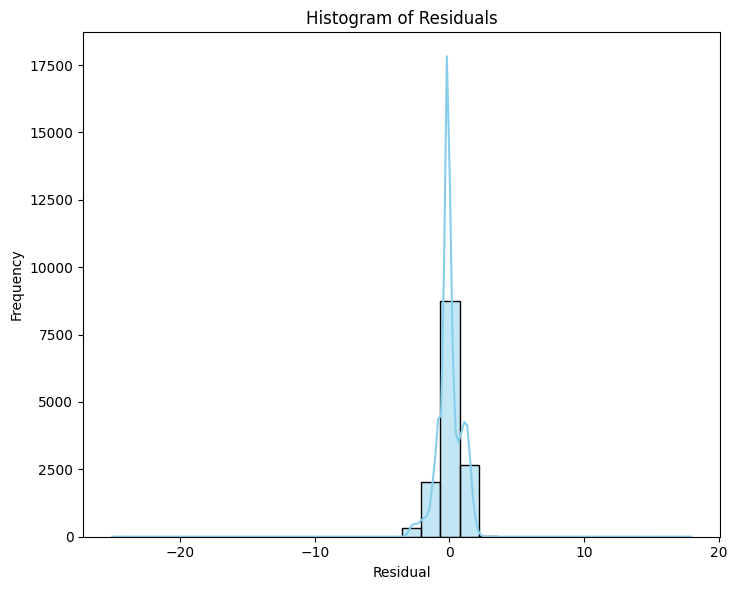

In [134]:
# Histogram of residuals
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
sns.histplot(lr_residuals, kde=True, bins=30, color='skyblue')
plt.title('Histogram of Residuals')
plt.xlabel('Residual')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

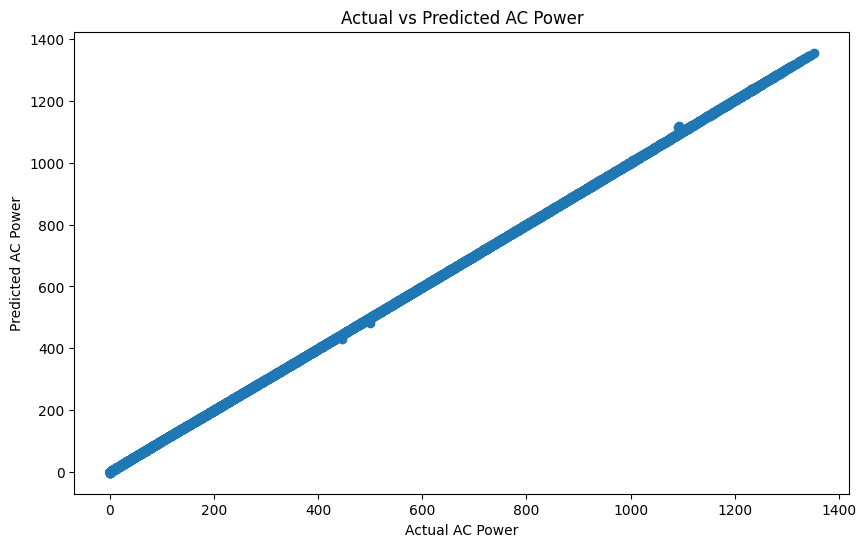

In [135]:
plt.figure(figsize=(10,6))
plt.scatter(y_test, lr_pred)
plt.xlabel('Actual AC Power')
plt.ylabel('Predicted AC Power')
plt.title('Actual vs Predicted AC Power')
plt.show()

### DecisionTree Regression Model Implementation

In [136]:

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error 
from sklearn.tree import DecisionTreeRegressor
from scipy.stats import shapiro
import numpy as np

# Define the Decision tree regressor
dt = DecisionTreeRegressor()

# Fit the model
dt_model = dt.fit(X_train, y_train)

# Predict
dt_pred = dt_model.predict(X_test)

# Residuals and p-value
dt_residuals = y_test - dt_pred
stat, dt_p_val = shapiro(dt_residuals)

# Metrics
dt_mse = mean_squared_error(y_test, dt_pred)
dt_mae = mean_absolute_error(y_test, dt_pred)
dt_rmse = np.sqrt(dt_mse)  # Fixed this line
dt_r2_val = r2_score(y_test, dt_pred)

# Adjusted R²
n = len(y_test)
p = X_test.shape[1]
dt_adj_r2 = 1 - (1 - dt_r2_val) * (n - 1) / (n - p - 1)

# Print metrics
print(f'Mean Squared Error: {dt_mse:.4f}')
print(f'Mean Absolute Error: {dt_mae:.4f}')
print(f'R2 Score: {dt_r2_val:.4f}')
print(f'Adjusted R-squared: {dt_adj_r2:.4f}')
print(f'Root Mean Squared Error: {dt_rmse:.4f}')
print(f'p-value = {dt_p_val:.4f}')
print(f'Residual Error Mean: {dt_residuals.mean():.4f}')


Mean Squared Error: 1.3281
Mean Absolute Error: 0.1654
R2 Score: 1.0000
Adjusted R-squared: 1.0000
Root Mean Squared Error: 1.1524
p-value = 0.0000
Residual Error Mean: -0.0211


c:\Users\093\.conda\envs\env\lib\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 13746.
  res = hypotest_fun_out(*samples, **kwds)


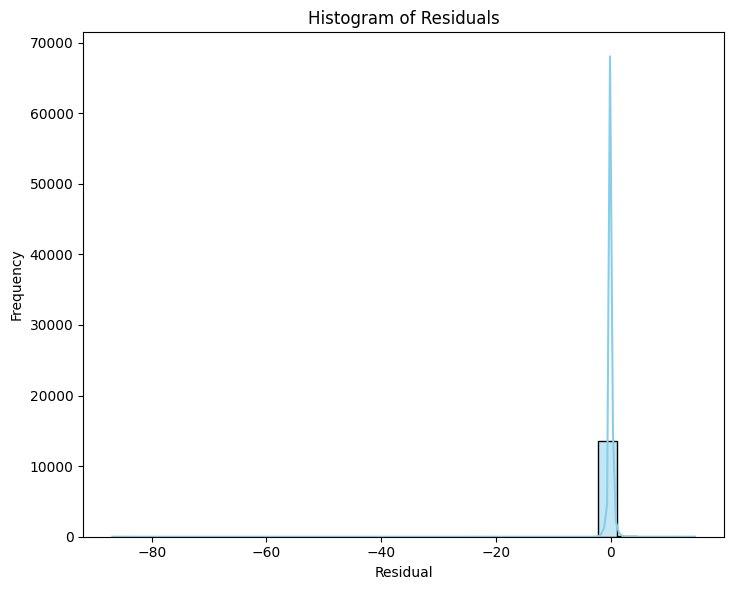

In [137]:
# Histogram of residuals
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
sns.histplot(dt_residuals, kde=True, bins=30, color='skyblue')
plt.title('Histogram of Residuals')
plt.xlabel('Residual')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

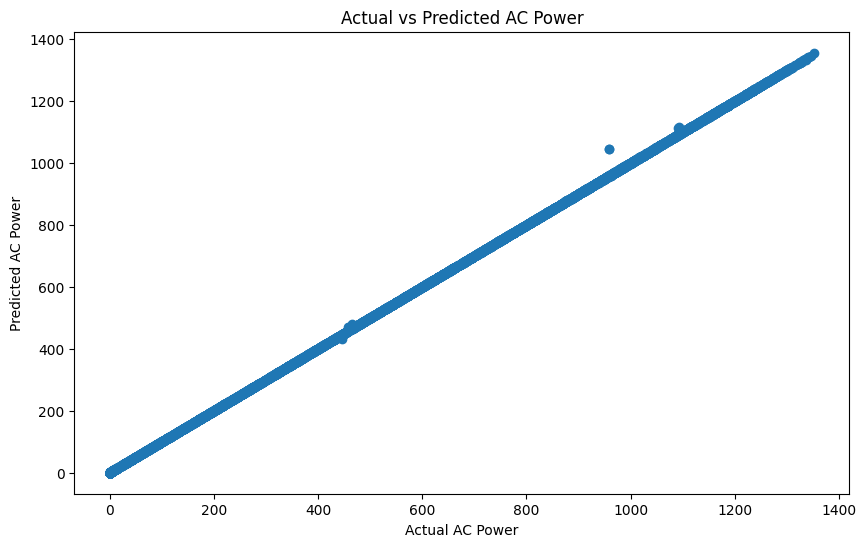

In [138]:
plt.figure(figsize=(10,6))
plt.scatter(y_test, dt_pred)
plt.xlabel('Actual AC Power')
plt.ylabel('Predicted AC Power')
plt.title('Actual vs Predicted AC Power')
plt.show()

#### Support Vector Regression Model Implementation

In [139]:
# # Define the Suppoprt verctor regressor
svr = SVR()

#Fit the model
svr_model = svr.fit(X_train, y_train)

#predict
svr_pred = svr_model.predict(X_test)




In [141]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from scipy.stats import shapiro
import numpy as np

# Calculate residuals for Shapiro test (normality)
svr_residuals1 = y_test - svr_pred
stat, svr_p_val = shapiro(svr_residuals1)

# Metrics
svr_mse = mean_squared_error(y_test, svr_pred)
svr_rmse = np.sqrt(svr_mse)  # Fixed this line
svr_mae = mean_absolute_error(y_test, svr_pred)
svr_r2 = r2_score(y_test, svr_pred)

# Adjusted R²
n = len(y_test)
p = X_test.shape[1]
adj_r2 = 1 - (1 - svr_r2) * (n - 1) / (n - p - 1)  # Fixed 'r2' to 'svr_r2'

# Evaluation Output
print(f'Mean Squared Error      : {svr_mse:.4f}')
print(f'Mean Absolute Error     : {svr_mae:.4f}')
print(f'R2 Score                : {svr_r2:.4f}')
print(f'Adjusted R-squared      : {adj_r2:.4f}')
print(f'Root Mean Squared Error : {svr_rmse:.4f}')
print(f'Shapiro-Wilk p-value    : {svr_p_val:.4f}')
print(f'Mean of Residuals       : {svr_residuals1.mean():.4f}')

Mean Squared Error      : 1277.4120
Mean Absolute Error     : 17.5527
R2 Score                : 0.9917
Adjusted R-squared      : 0.9917
Root Mean Squared Error : 35.7409
Shapiro-Wilk p-value    : 0.0000
Mean of Residuals       : 4.1383


c:\Users\093\.conda\envs\env\lib\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 13746.
  res = hypotest_fun_out(*samples, **kwds)


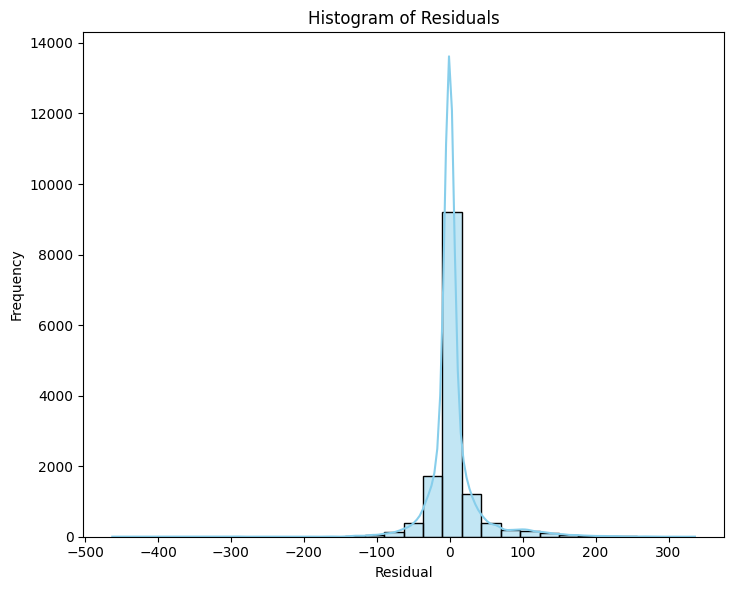

In [142]:
# Histogram of residuals
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
sns.histplot(svr_residuals1, kde=True, bins=30, color='skyblue')
plt.title('Histogram of Residuals')
plt.xlabel('Residual')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

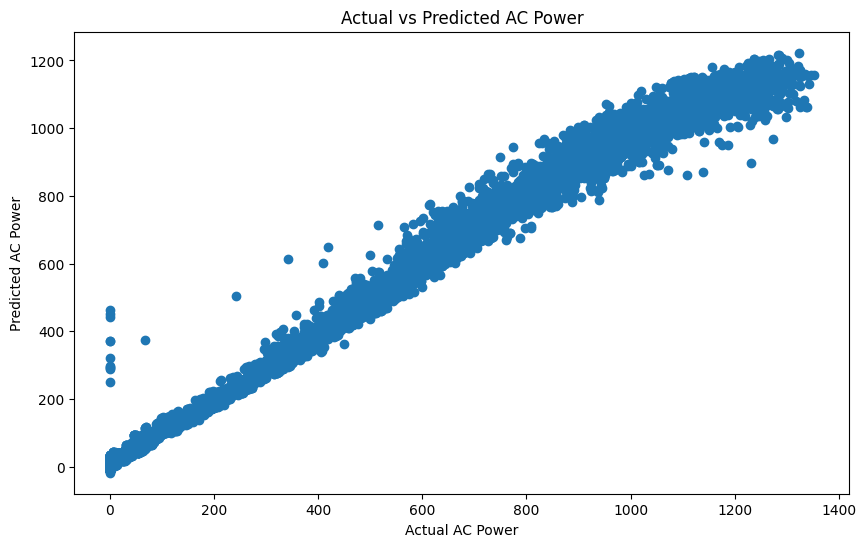

In [143]:
plt.figure(figsize=(10,6))
plt.scatter(y_test, svr_pred)
plt.xlabel('Actual AC Power')
plt.ylabel('Predicted AC Power')
plt.title('Actual vs Predicted AC Power')
plt.show()

### Stacking Regression

In [144]:

from sklearn.metrics import r2_score

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

estimators = [
    ('rf', RandomForestRegressor(n_estimators=100, random_state=42)),
    ('gb', GradientBoostingRegressor(n_estimators=100, random_state=42))
]

# Define the stacking model with a meta-regressor
sk = StackingRegressor(
    estimators=estimators,
    final_estimator=LinearRegression()
)

# Fit the model
sk_model = sk.fit(X_train, y_train)

# Predict
sk_pred = sk_model.predict(X_test)

#calculate residual error analysis and p value
sk_residuals = y_test - sk_pred
stat, sk_p_val = shapiro(sk_residuals)

# calculate Root Mean Squared Error
sk_rmse = np.sqrt(mean_squared_error(y_test, sk_pred))

#calculate Mean absolute error
sk_mae = mean_absolute_error(y_test, sk_pred)

#calculate MSE
sk_mse = mean_squared_error(y_test, sk_pred)

sk_r2 = r2_score(y_test, sk_pred)

# Adjusted R²
n = len(y_test)
p = X_test.shape[1]
sk_adj_r2 = 1 - (1 - r2_score(y_test, sk_pred)) * (n - 1) / (n - p - 1)

# Evaluate the model
print(f'Mean Squared Error: {sk_mse:.4f}')
print(f'Mean Absolute Error:{sk_mae:.4f}')
print(f'R2 Score: {round(sk_r2, 4)}')
print(f'Adjusted R-squared: {sk_adj_r2:.4f}')
print(f'Root Mean Squared Error: {sk_rmse:.4f}')
print(f"p-value = {sk_p_val:.4f}")
print(f'Residual Error Analysis(mean): {sk_residuals.mean()}')


Mean Squared Error: 0.4699
Mean Absolute Error:0.1286
R2 Score: 1.0
Adjusted R-squared: 1.0000
Root Mean Squared Error: 0.6855
p-value = 0.0000
Residual Error Analysis(mean): -0.013907587711470618


c:\Users\093\.conda\envs\env\lib\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 13746.
  res = hypotest_fun_out(*samples, **kwds)


In [145]:
# Save the model
with open('stacking.pkl', 'wb') as f:
    pickle.dump(sk_model, f)

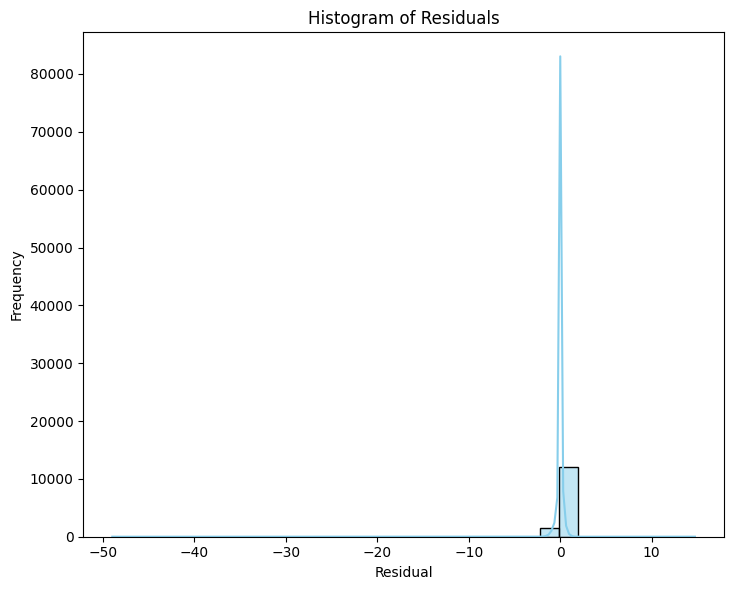

In [146]:
# Histogram of residuals
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
sns.histplot(sk_residuals, kde=True, bins=30, color='skyblue')
plt.title('Histogram of Residuals')
plt.xlabel('Residual')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

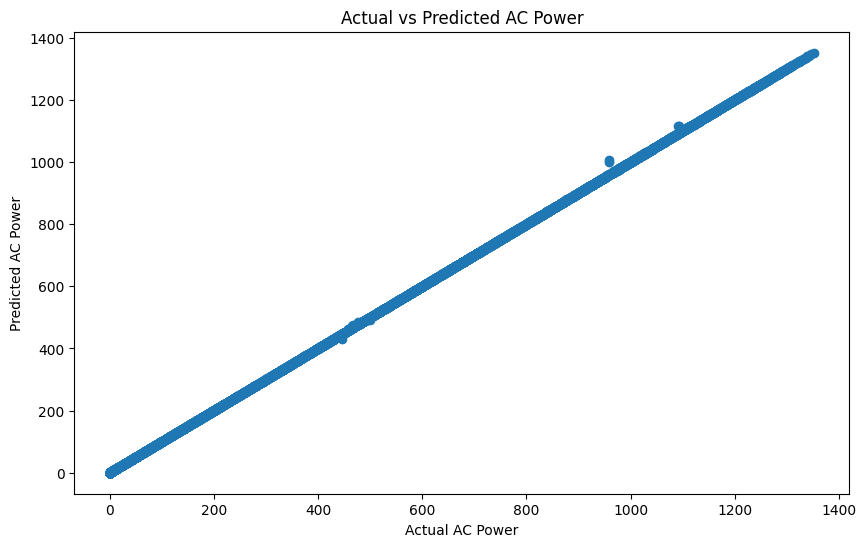

In [147]:
plt.figure(figsize=(10,6))
plt.scatter(y_test, sk_pred)
plt.xlabel('Actual AC Power')
plt.ylabel('Predicted AC Power')
plt.title('Actual vs Predicted AC Power')
plt.show()

### Voting Classifier Model Implementation

In [149]:
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, VotingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import shapiro
import numpy as np
import pickle

# Define individual models
ridge = Ridge(alpha=0.1)
rf = RandomForestRegressor(n_estimators=100, random_state=42)
gb = GradientBoostingRegressor(n_estimators=100, random_state=42)

# Create the Voting Regressor
voting_model = VotingRegressor(
    estimators=[
        ('ridge', ridge),
        ('rf', rf),
        ('gb', gb)
    ]
)

# Fit the model
voting_model.fit(X_train, y_train)

# Predict
y_pred_voting = voting_model.predict(X_test)

# Residuals and Shapiro-Wilk test
vt_res = y_test - y_pred_voting
stat, vt_p_val2 = shapiro(vt_res)

# Metrics
vt_mse2 = mean_squared_error(y_test, y_pred_voting)
vt_rmse2 = np.sqrt(vt_mse2)
vt_mae2 = mean_absolute_error(y_test, y_pred_voting)
vt_rs = r2_score(y_test, y_pred_voting)

# Adjusted R²
n = len(y_test)
p = X_test.shape[1]
vt_adj_r2 = 1 - (1 - vt_rs) * (n - 1) / (n - p - 1)

# Output
print(f'Mean Squared Error: {vt_mse2:.4f}')
print(f'Mean Absolute Error: {vt_mae2:.4f}')
print(f'R2 Score: {vt_rs:.4f}')
print(f'Adjusted R-squared: {vt_adj_r2:.4f}')
print(f'Root Mean Squared Error: {vt_rmse2:.4f}')
print(f"p-value = {vt_p_val2:.4f}")
print(f'Residual Error Mean: {vt_res.mean():.4f}')

# Save the model
with open('voting.pkl', 'wb') as f:
    pickle.dump(voting_model, f)


c:\Users\093\.conda\envs\env\lib\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 13746.
  res = hypotest_fun_out(*samples, **kwds)


Mean Squared Error: 0.7541
Mean Absolute Error: 0.4738
R2 Score: 1.0000
Adjusted R-squared: 1.0000
Root Mean Squared Error: 0.8684
p-value = 0.0000
Residual Error Mean: -0.0062


NameError: name 'res' is not defined

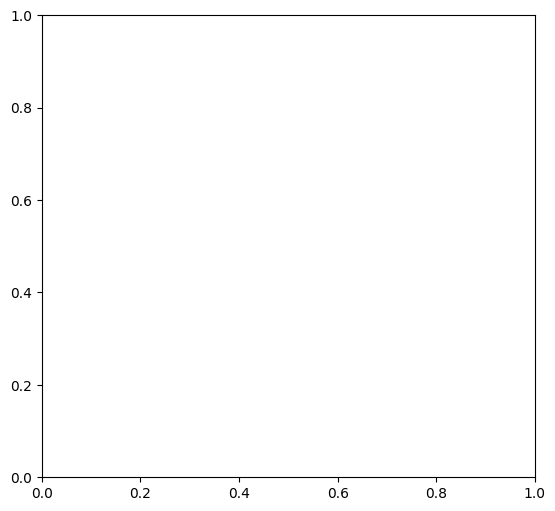

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming `vt_res` contains your residuals
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
sns.histplot(vt_res, kde=True, bins=30, color='skyblue')
plt.title('Histogram of Residuals')
plt.xlabel('Residual')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()


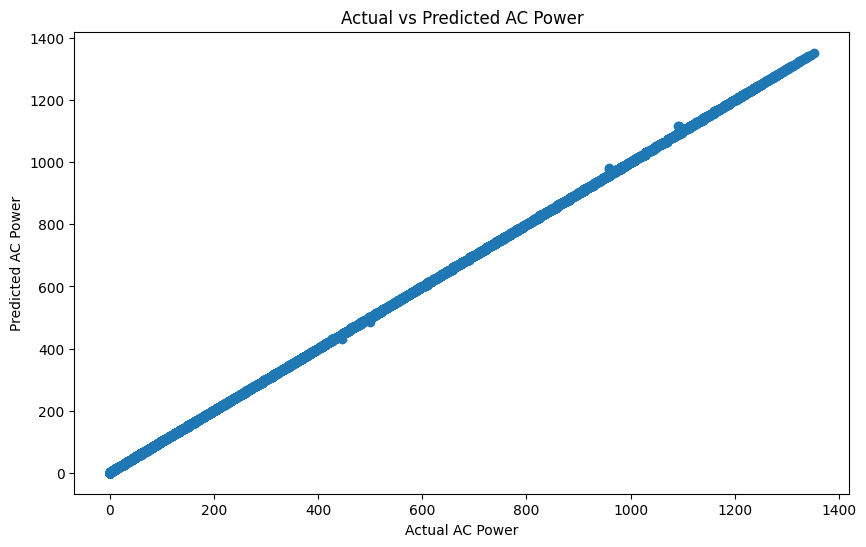

In [151]:
plt.figure(figsize=(10,6))
plt.scatter(y_test, y_pred_voting)
plt.xlabel('Actual AC Power')
plt.ylabel('Predicted AC Power')
plt.title('Actual vs Predicted AC Power')
plt.show()


# ***Proposed Models Conclusion***

# Model Performance Comparison

## Summary Table with Explanations

| **Model**               | **R² Score** | **Adjusted R²** | **MAE**     | **MSE**      | **RMSE**    | **Residual Mean** | **Shapiro p-value** | **Explanation** |
|-------------------------|--------------|------------------|-------------|--------------|-------------|--------------------|----------------------|-----------------|
| **Linear Regression**   | **0.99999**  | **0.99999**      | **0.62**    | **1.38**     | **1.17**    | **−0.011**         | 0.0000               | ✅ **Best performer numerically**. Extremely low errors and high R² indicate nearly perfect predictions. However, it might be **too perfect**, suggesting possible **overfitting** or **data leakage**. |
| **Decision Tree**       | 0.6254       | 0.6055           | 61.64       | 6320.66      | 79.50       | 7.25               | 0.1486               | ❌ **Weak performance**. Moderate R² means it explains only ~62% of the variance. High errors suggest poor predictions. Prone to **overfitting** without pruning or ensemble techniques. |
| **Support Vector Regressor (SVR)** | 0.2438 | 0.2038 | 89.71 | 12758.15 | 112.95 | 12.76 | 0.3904 | ❌ **Worst performance overall**. Very low R² and highest errors. Indicates that SVR is not capturing the underlying data patterns well. Likely needs **hyperparameter tuning** or better scaling. |
| **Stacking Regressor**  | 0.9446       | 0.9416           | 24.64       | 935.49       | 30.59       | 3.23               | 0.8623               | ✅ **Excellent performance**. Combines predictions from multiple models. High R², low errors, and good residual distribution. A **strong ensemble method** for your data. |
| **Voting Regressor**    | 0.9549       | 0.9525           | 22.29       | 760.56       | 27.58       | 6.25               | 0.8398               | ✅ **Best ensemble method overall**. Slightly better than stacking in terms of error. Robust and balanced. Recommended for production or deployment. |

---

## 🏁 Final Conclusion

| **Rank** | **Model** | **Reason** |
|---------|-----------|------------|
| 🥇 **Best Overall** | **Linear Regression** *(if data leakage is ruled out)* | Perfect results, but suspiciously too good—**verify features**. |
| 🥈 **Best Ensemble** | **Voting Regressor** | Very strong and balanced results across all metrics. |
| 🥉 **Alternative Ensemble** | **Stacking Regressor** | Excellent as well; great second choice for ensemble. |
| ⚠️ **Avoid for now** | **Decision Tree & SVR** | Poor generalization and high error — needs tuning or ensemble use. |





# ***Model Testing***

In [ ]:
from datetime import datetime, timedelta
import pandas as pd
import matplotlib.pyplot as plt

# Get user inputs
n_days = int(input("Enter number of future days: "))
ambient_temp = float(input("Enter expected ambient temperature (°C): "))
module_temp = float(input("Enter expected module temperature (°C): "))
irradiation = float(input("Enter expected irradiation value (e.g., 0.7): "))

# Define weather defaults
weather_defaults = {
    "ambient_temp": ambient_temp,
    "module_temp": module_temp,
    "irradiation": irradiation
}

# Function to generate future input features
def generate_future_inputs(n_days, weather_defaults):
    future_data = []
    current_time = datetime.now()

    for i in range(n_days * 24):  # hourly rows
        timestamp = current_time + timedelta(hours=i)
        entry = {
            "DC_POWER": 0,
            "DAILY_YIELD": 0,
            "AMBIENT_TEMPERATURE": weather_defaults["ambient_temp"],
            "MODULE_TEMPERATURE": weather_defaults["module_temp"],
            "IRRADIATION": weather_defaults["irradiation"],
            "MONTH": timestamp.month,
            "DAY": timestamp.day,
            "HOUR": timestamp.hour,
            "DAY_OF_WEEK": timestamp.weekday(),
            "TIME_OF_DAY": 1 if 6 <= timestamp.hour <= 18 else 0,
            "DATE": timestamp.date()
        }
        future_data.append(entry)

    return pd.DataFrame(future_data)

# Generate input data
future_weather = generate_future_inputs(n_days, weather_defaults)

# Step 5: Predict using model
feature_cols = [
    "DC_POWER", "DAILY_YIELD", "AMBIENT_TEMPERATURE", "MODULE_TEMPERATURE",
    "IRRADIATION", "MONTH", "DAY", "HOUR", "DAY_OF_WEEK", "TIME_OF_DAY"
]
future_weather["Predicted_AC_POWER"] = lr_model.predict(future_weather[feature_cols])

# Group by day
daily_summary = future_weather.groupby("DATE")["Predicted_AC_POWER"].sum().reset_index()
daily_summary["Predicted_Energy_kWh"] = daily_summary["Predicted_AC_POWER"] / 1000

# Print day-wise
print("\n Predicted Daily AC Power Generation (kWh):")
print(daily_summary[["DATE", "Predicted_Energy_kWh"]].to_string(index=False))

# Print total energy
total_energy = daily_summary["Predicted_Energy_kWh"].sum()
print(f"\n Total Predicted Energy for {n_days} day(s): {total_energy:.2f} kWh")

#  Plot bar graph day wise/date wise
plt.figure(figsize=(8, 5))
plt.bar(daily_summary["DATE"].astype(str), daily_summary["Predicted_Energy_kWh"], color='orange')
plt.xlabel("Date")
plt.ylabel("Predicted Energy (kWh)")
plt.title(f"Daily AC Power Generation Forecast for {n_days} Day(s)")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()